# 03 — Regression Analysis: OD vs SD (Multi-Method, Multi-σ²)

Fit OLS on each pair of **Original Data (OD)** and **Synthetic Data (SD)** across:
- **3 synthesis methods**: CART, NORM, PMM
- **3 correlation levels**: ρ ∈ {0.0, 0.3, 0.6}
- **3 error variances**: σ² ∈ {1.0, 1.5, 2.0}
- **M repetitions** per scenario

New metrics include **Confidence Interval overlap %** averaged across β₁…βₚ.

Plot structure: **one 3×3 grid per method** (rows = ρ, columns = σ²).

In [29]:
# ── Imports ──────────────────────────────────────────────────────────────────
import json, os, re, glob, pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from matplotlib.lines import Line2D
from scipy import stats as sp_stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ── Style ────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 200,
    "axes.titleweight": "bold", "axes.labelsize": 11,
    "font.family": "sans-serif",
})

In [30]:
# ── Load Configuration ──────────────────────────────────────────────────────
config_path = os.path.join("..", "config", "config.json")
with open(config_path) as f:
    config = json.load(f)

M           = config["simulation"]["M"]
N           = config["simulation"]["N"]
p           = config["simulation"]["p"]
rho_vals    = config["parameters"]["rho"]
sigma_2_vals= config["parameters"]["sigma_2"]
beta_true   = np.array(config["parameters"]["beta"])
methods     = config["synthesis"]["methods"]

print("Configuration:")
print(json.dumps(config, indent=2))
print(f"\nGrid: {len(methods)} methods × {len(rho_vals)} ρ × {len(sigma_2_vals)} σ² × M={M} reps")
print(f"Methods: {methods}")

Configuration:
{
  "simulation": {
    "N": 1000,
    "p": 10,
    "random_seed_base": 16,
    "test_seed": 123,
    "N_test": 10000,
    "M": 100
  },
  "parameters": {
    "rho": [
      0.0,
      0.3,
      0.6
    ],
    "sigma_2": [
      1.0,
      1.5,
      2.0
    ],
    "beta": [
      1,
      1,
      1,
      1,
      1,
      1,
      1,
      1,
      1,
      1,
      1
    ]
  },
  "synthesis": {
    "methods": [
      "cart",
      "norm",
      "pmm"
    ]
  }
}

Grid: 3 methods × 3 ρ × 3 σ² × M=100 reps
Methods: ['cart', 'norm', 'pmm']


In [31]:
# ── Discover matched OD / SD file pairs ────────────────────────────────────
od_dir     = os.path.join("..", "data", "original")
sd_dir     = os.path.join("..", "data", "synthetic")
model_dir  = os.path.join("..", "models")
result_dir = os.path.join("..", "results")
os.makedirs(model_dir, exist_ok=True)
os.makedirs(result_dir, exist_ok=True)

od_files = sorted(glob.glob(os.path.join(od_dir, "OD_*.csv")))
sd_files = sorted(glob.glob(os.path.join(sd_dir, "SD_*.csv")))

assert len(od_files) > 0, f"No OD files found in {od_dir}"
assert len(sd_files) > 0, f"No SD files found in {sd_dir}"

print(f"OD files: {len(od_files)}")
print(f"SD files: {len(sd_files)}  ({len(od_files)} OD × {len(methods)} methods)")
print(f"First OD: {os.path.basename(od_files[0])}")
print(f"First SD: {os.path.basename(sd_files[0])}")

OD files: 900
SD files: 2700  (900 OD × 3 methods)
First OD: OD_N1000_p10_rho0.0_sigma1.0_rep1.csv
First SD: SD_cart_N1000_p10_rho0.0_sigma1.0_rep1.csv


In [32]:
# ── Helpers: parse filenames, compute CIs, CI overlap ──────────────────────

def parse_od(filename):
    """Extract rho, sigma_2, rep from OD_N1000_p10_rho0.3_sigma1.5_rep5.csv"""
    m = re.search(r"rho([\d.]+)_sigma([\d.]+)_rep(\d+)", filename)
    if m:
        return float(m.group(1)), float(m.group(2)), int(m.group(3))
    raise ValueError(f"Cannot parse: {filename}")


def parse_sd(filename):
    """Extract method, rho, sigma_2, rep from SD_cart_N1000_p10_rho0.3_sigma1.5_rep5.csv"""
    m = re.search(r"SD_(\w+)_N\d+_p\d+_rho([\d.]+)_sigma([\d.]+)_rep(\d+)", filename)
    if m:
        return m.group(1), float(m.group(2)), float(m.group(3)), int(m.group(4))
    raise ValueError(f"Cannot parse: {filename}")


def compute_ci(X_np, y_np, model, alpha=0.05):
    """Compute 95% CI for each OLS coefficient (intercept + slopes)."""
    n, k = X_np.shape
    y_hat = model.predict(X_np)
    residuals = y_np - y_hat
    mse = np.sum(residuals ** 2) / (n - k - 1)

    X_design = np.column_stack([np.ones(n), X_np])
    XtX_inv  = np.linalg.inv(X_design.T @ X_design)
    se       = np.sqrt(mse * np.diag(XtX_inv))

    t_crit = sp_stats.t.ppf(1 - alpha / 2, df=n - k - 1)
    coef   = np.concatenate([[model.intercept_], model.coef_])
    lower  = coef - t_crit * se
    upper  = coef + t_crit * se
    return lower, upper, coef, se


def ci_overlap_pct(lower_od, upper_od, lower_sd, upper_sd, slopes_only=True):
    """Mean CI overlap % across coefficients (default: slopes β₁…βₚ only)."""
    overlap   = np.maximum(0, np.minimum(upper_od, upper_sd) - np.maximum(lower_od, lower_sd))
    width_od  = upper_od - lower_od
    width_sd  = upper_sd - lower_sd
    avg_width = 0.5 * (width_od + width_sd)
    pct       = np.clip(overlap / avg_width, 0.0, 1.0)

    if slopes_only:
        return pct[1:].mean() * 100   # exclude intercept
    return pct.mean() * 100


print("Helpers loaded.")

Helpers loaded.


## Fit OLS Models

For each combination (method × ρ × σ² × rep), fit $y = X\beta + \epsilon$ on OD and SD.  
Compute coefficient estimates, $R^2$, 95% CIs, and **CI overlap %** (averaged across β₁…βₚ).

In [33]:
# ── Build a lookup: (rho, sigma, rep) → OD path ────────────────────────────
od_lookup = {}
for fp in od_files:
    rho, sigma, rep = parse_od(os.path.basename(fp))
    od_lookup[(rho, sigma, rep)] = fp

# ── Fit all model pairs ─────────────────────────────────────────────────────
results   = []     # per-scenario summary
coef_rows = []     # long-format coefficient rows

terms = ["β₀ (intercept)"] + [f"β{i+1}" for i in range(p)]

total = len(sd_files)
for i, sd_path in enumerate(sd_files):
    method, rho, sigma, rep = parse_sd(os.path.basename(sd_path))

    # Find matching OD file
    od_path = od_lookup.get((rho, sigma, rep))
    if od_path is None:
        continue

    od = pd.read_csv(od_path)
    sd = pd.read_csv(sd_path)

    X_od, y_od = od.drop(columns="y").values, od["y"].values
    X_sd, y_sd = sd.drop(columns="y").values, sd["y"].values

    lm_od = LinearRegression().fit(X_od, y_od)
    lm_sd = LinearRegression().fit(X_sd, y_sd)

    r2_od = r2_score(y_od, lm_od.predict(X_od))
    r2_sd = r2_score(y_sd, lm_sd.predict(X_sd))

    # Coefficient vectors
    beta_od = np.concatenate([[lm_od.intercept_], lm_od.coef_])
    beta_sd = np.concatenate([[lm_sd.intercept_], lm_sd.coef_])

    # 95% Confidence Intervals
    lo_od, hi_od, _, _ = compute_ci(X_od, y_od, lm_od)
    lo_sd, hi_sd, _, _ = compute_ci(X_sd, y_sd, lm_sd)

    ci_overlap = ci_overlap_pct(lo_od, hi_od, lo_sd, hi_sd, slopes_only=True)

    # Save model pair
    tag = f"{method}_N{N}_p{p}_rho{rho}_sigma{sigma}_rep{rep}"
    mpath = os.path.join(model_dir, f"models_{tag}.pkl")
    with open(mpath, "wb") as f:
        pickle.dump({
            "lm_od": lm_od, "lm_sd": lm_sd, "scenario": tag,
            "method": method, "rho": rho, "sigma_2": sigma, "rep": rep,
        }, f)

    results.append({
        "method": method, "rho": rho, "sigma_2": sigma, "rep": rep,
        "r2_od": r2_od, "r2_sd": r2_sd, "r2_diff": r2_od - r2_sd,
        "ci_overlap_pct": ci_overlap,
    })

    for j, name in enumerate(terms):
        coef_rows.append({
            "method": method, "rho": rho, "sigma_2": sigma, "rep": rep,
            "term": name, "beta_true": beta_true[j],
            "beta_od": beta_od[j], "beta_sd": beta_sd[j],
            "diff": beta_od[j] - beta_sd[j],
        })

    if (i + 1) % 500 == 0 or i == total - 1:
        print(f"  Fitted {i + 1}/{total} model pairs...")

results_df = pd.DataFrame(results)
coef_df    = pd.DataFrame(coef_rows)

print(f"\nDone. Results: {results_df.shape}, Coefficients: {coef_df.shape}")

  Fitted 500/2700 model pairs...
  Fitted 1000/2700 model pairs...
  Fitted 1500/2700 model pairs...
  Fitted 2000/2700 model pairs...
  Fitted 2500/2700 model pairs...
  Fitted 2700/2700 model pairs...

Done. Results: (2700, 8), Coefficients: (29700, 9)


## Summary Tables (aggregated over M repetitions)

In [34]:
# ── Aggregate summary by (method, rho, sigma_2) ────────────────────────────
summary = (
    results_df
    .groupby(["method", "rho", "sigma_2"])
    .agg(
        M=("rep", "count"),
        r2_od_mean=("r2_od", "mean"),
        r2_sd_mean=("r2_sd", "mean"),
        r2_diff_mean=("r2_diff", "mean"),
        r2_diff_std=("r2_diff", "std"),
        ci_overlap_mean=("ci_overlap_pct", "mean"),
        ci_overlap_std=("ci_overlap_pct", "std"),
    )
    .reset_index()
)
display(summary)

# Save
results_df.to_csv(os.path.join(result_dir, "regression_results_all_reps.csv"), index=False)
coef_df.to_csv(os.path.join(result_dir, "coefficient_estimates_all_reps.csv"), index=False)
print("Saved: regression_results_all_reps.csv, coefficient_estimates_all_reps.csv")

,method,rho,sigma_2,M,r2_od_mean,r2_sd_mean,r2_diff_mean,r2_diff_std,ci_overlap_mean,ci_overlap_std
0,cart,0.0,1.0,100,0.909687,0.362794,0.546894,0.036996,4.887694,3.359692
1,cart,0.0,1.5,100,0.871454,0.354050,0.517404,0.031899,7.526237,4.878245
2,cart,0.0,2.0,100,0.833654,0.342256,0.491398,0.036213,8.058427,4.729738
3,cart,0.3,1.0,100,0.973819,0.716307,0.257512,0.023316,21.842529,5.860930
4,cart,0.3,1.5,100,0.961392,0.714837,0.246554,0.024309,25.095974,6.817879
5,cart,0.3,2.0,100,0.949197,0.708571,0.240627,0.024419,27.204691,7.705139
6,cart,0.6,1.0,100,0.984787,0.867349,0.117438,0.012126,26.782940,6.831866
7,cart,0.6,1.5,100,0.977393,0.864130,0.113264,0.012789,30.993546,8.447094
8,cart,0.6,2.0,100,0.970141,0.861169,0.108972,0.012033,34.572728,8.369518
9,norm,0.0,1.0,100,0.909687,0.910680,-0.000993,0.007642,71.191815,7.623849


Saved: regression_results_all_reps.csv, coefficient_estimates_all_reps.csv


## CI Overlap % — Heatmaps per Method

Each heatmap shows the mean CI overlap % (across β₁…βₚ and M repetitions) for every (ρ, σ²) combination.  
Higher = better utility preservation.

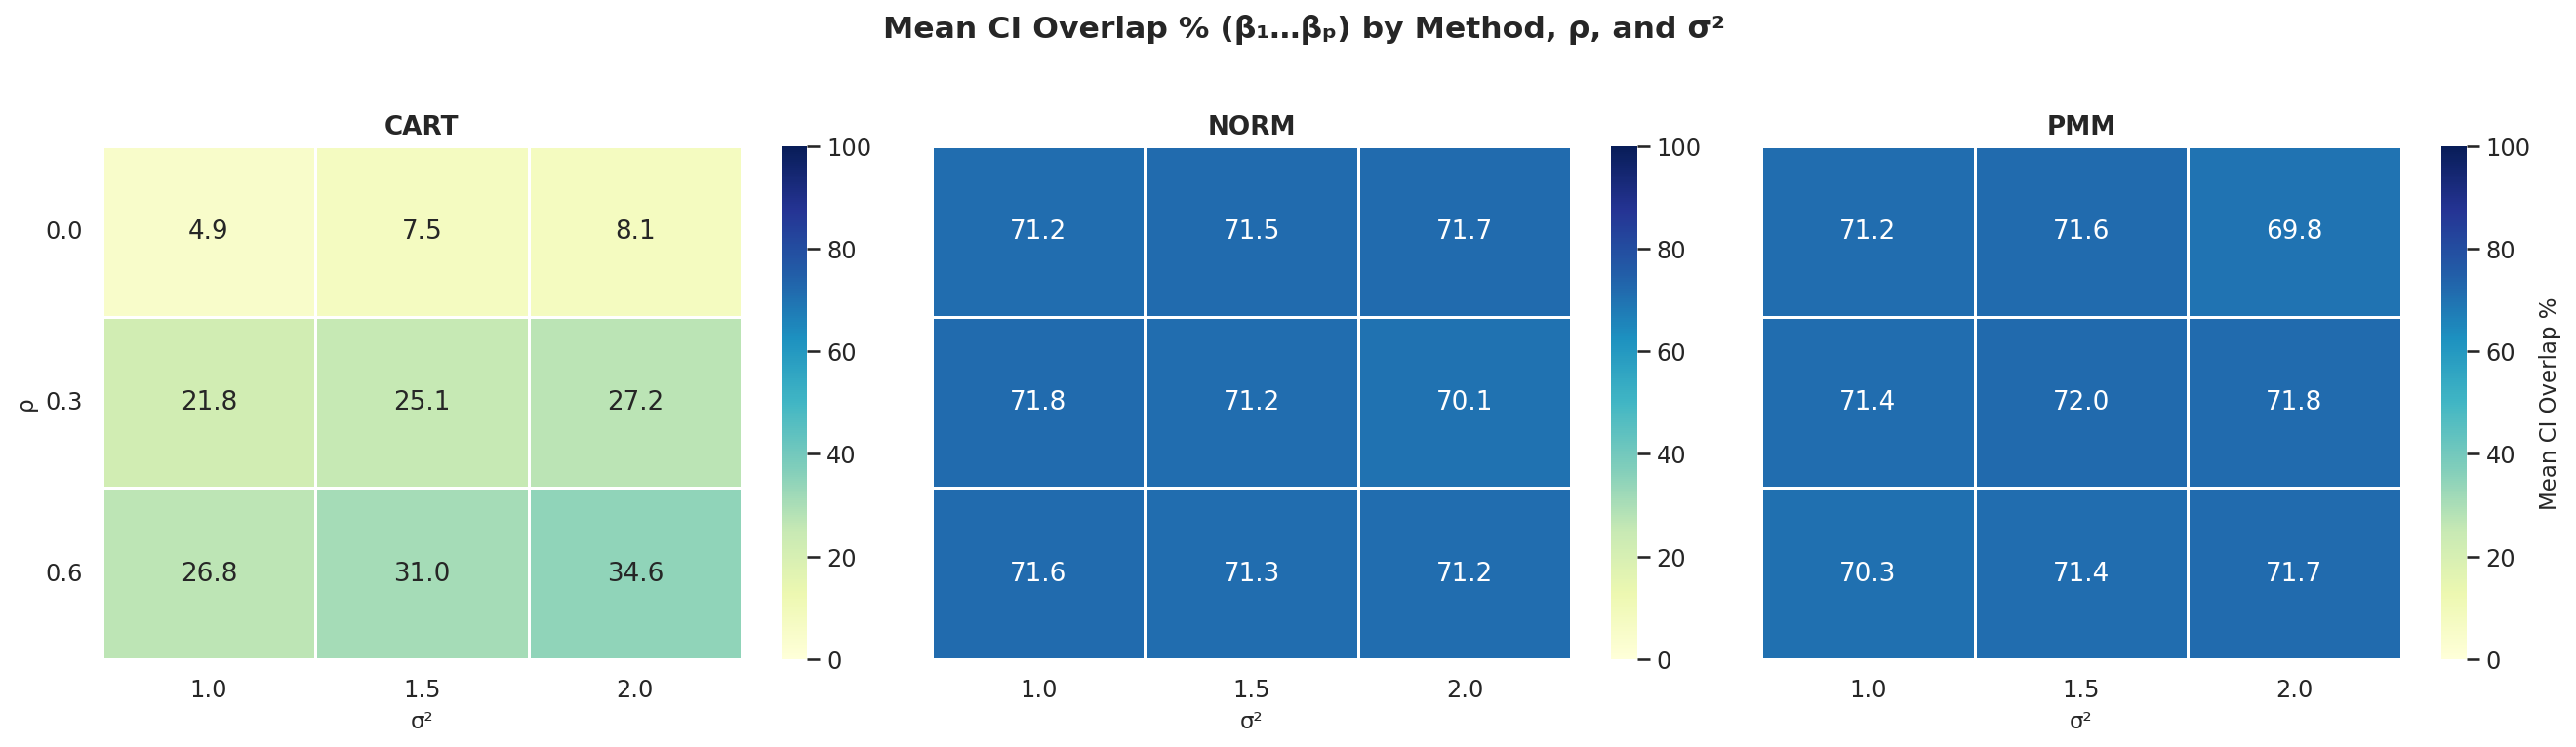

In [35]:
# ── CI Overlap Heatmap — one per method ────────────────────────────────────
fig, axes = plt.subplots(1, len(methods), figsize=(6 * len(methods), 5),
                         sharey=True)
if len(methods) == 1:
    axes = [axes]

for ax, method in zip(axes, methods):
    sub = summary[summary["method"] == method]
    pivot = sub.pivot(index="rho", columns="sigma_2", values="ci_overlap_mean")

    sns.heatmap(
        pivot, annot=True, fmt=".1f", cmap="YlGnBu", vmin=0, vmax=100,
        linewidths=0.5, ax=ax,
        cbar_kws={"label": "Mean CI Overlap %"} if ax == axes[-1] else {"label": ""},
    )
    ax.set_title(f"{method.upper()}")
    ax.set_xlabel("σ²")
    ax.set_ylabel("ρ" if ax == axes[0] else "")
    ax.set_yticklabels([f"{v:.1f}" for v in pivot.index], rotation=0)

plt.suptitle("Mean CI Overlap % (β₁…βₚ) by Method, ρ, and σ²",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(result_dir, "plot_ci_overlap_heatmap.png"),
            dpi=200, bbox_inches="tight")
plt.show()

## Visualisations — Per-Method 3×3 Grids

For each synthesis method, a **3×3 grid** where:  
- **Rows** = ρ ∈ {0.0, 0.3, 0.6}  
- **Columns** = σ² ∈ {1.0, 1.5, 2.0}  

Each cell shows a scatter of **true β vs estimated β̂** for both OD and SD (Option B).

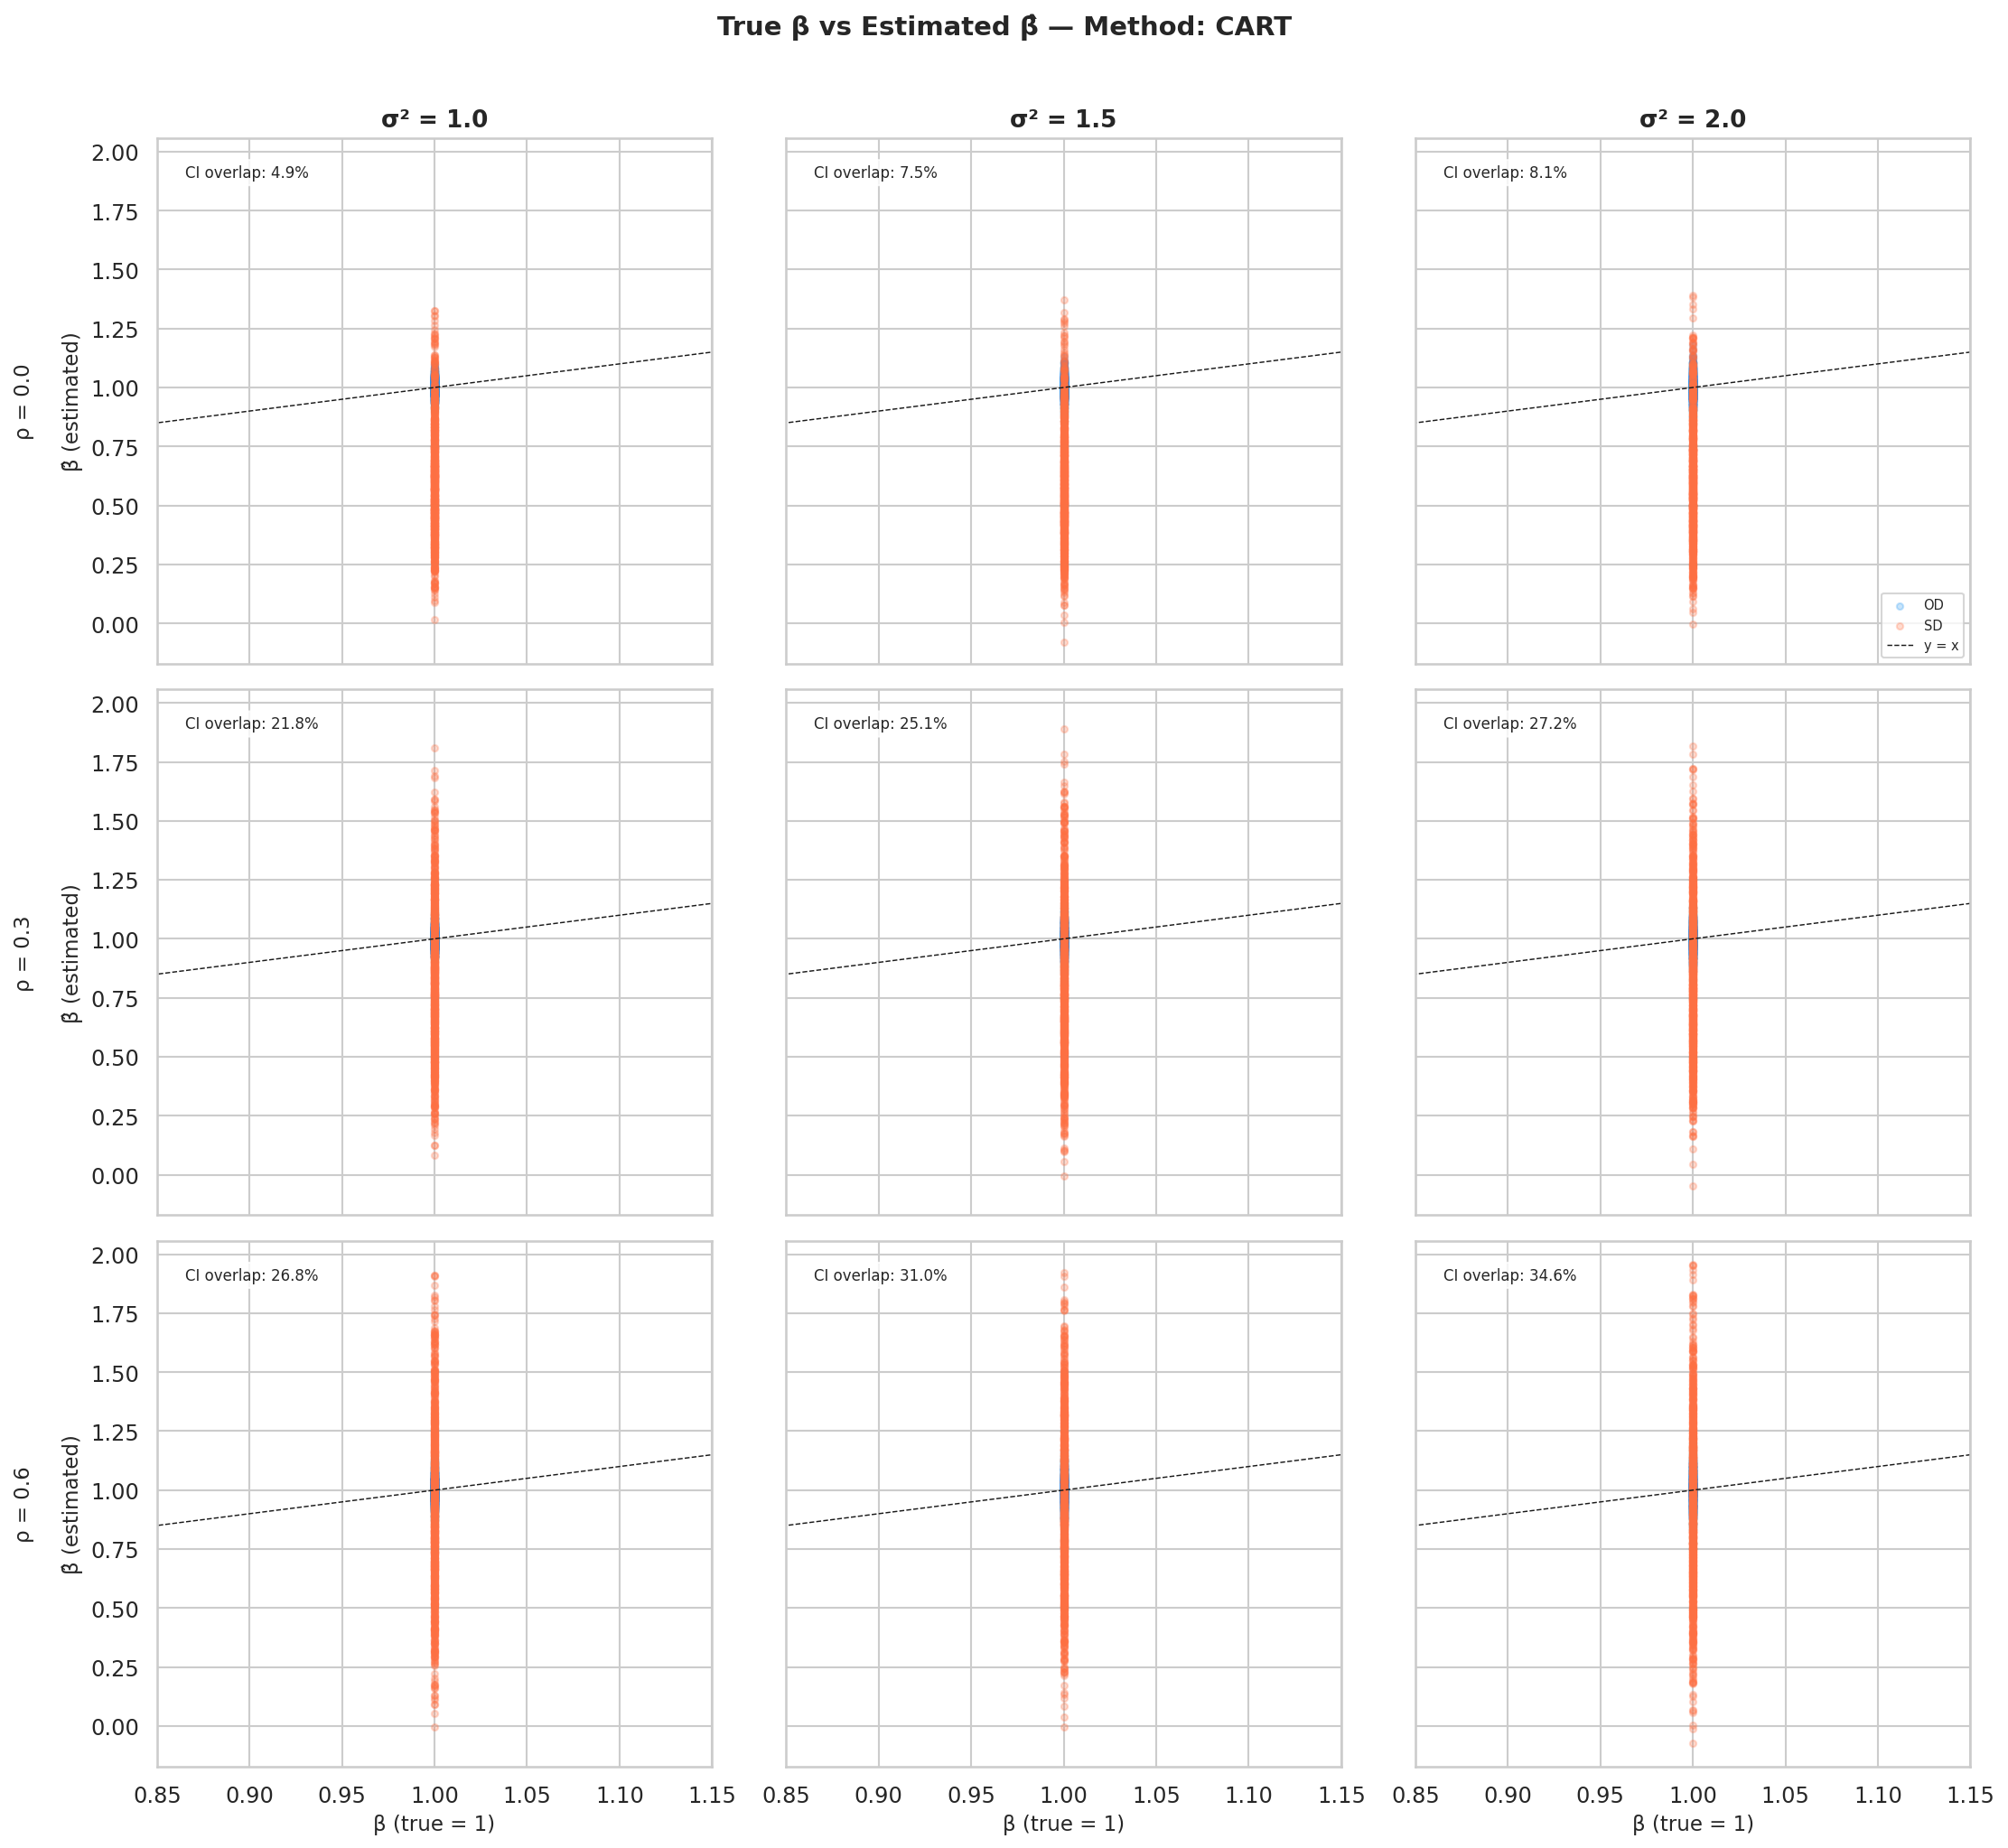

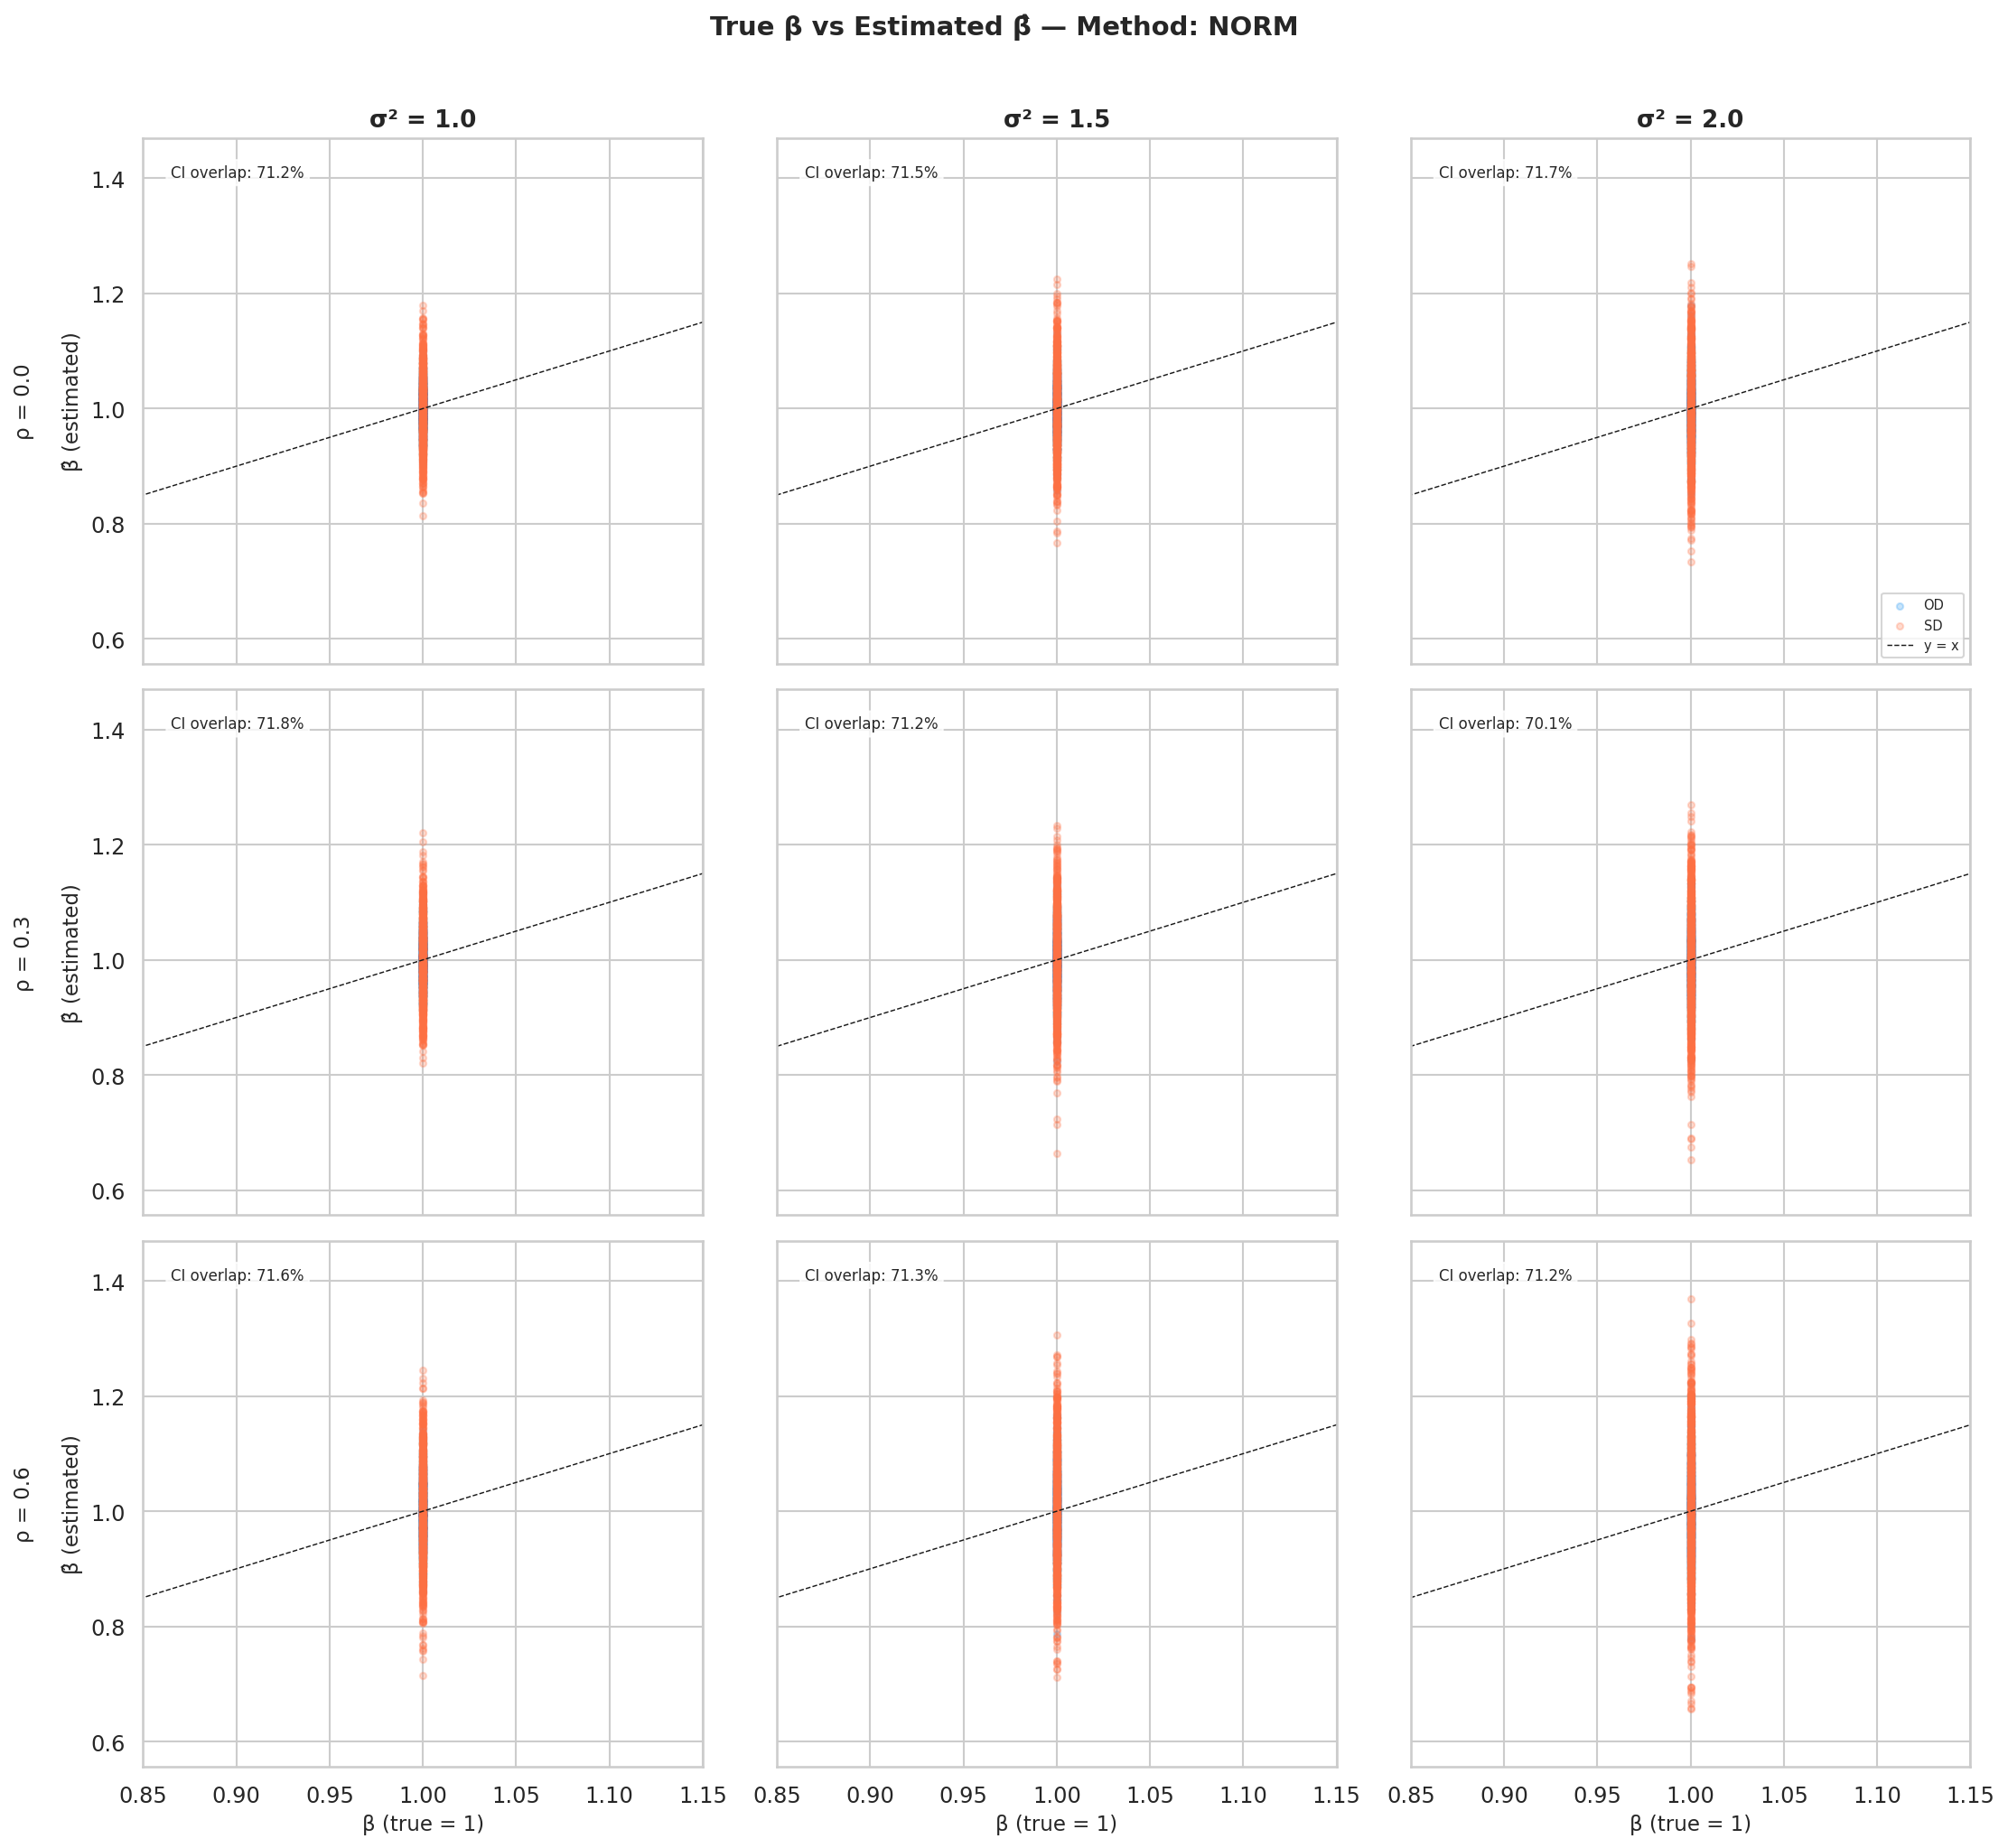

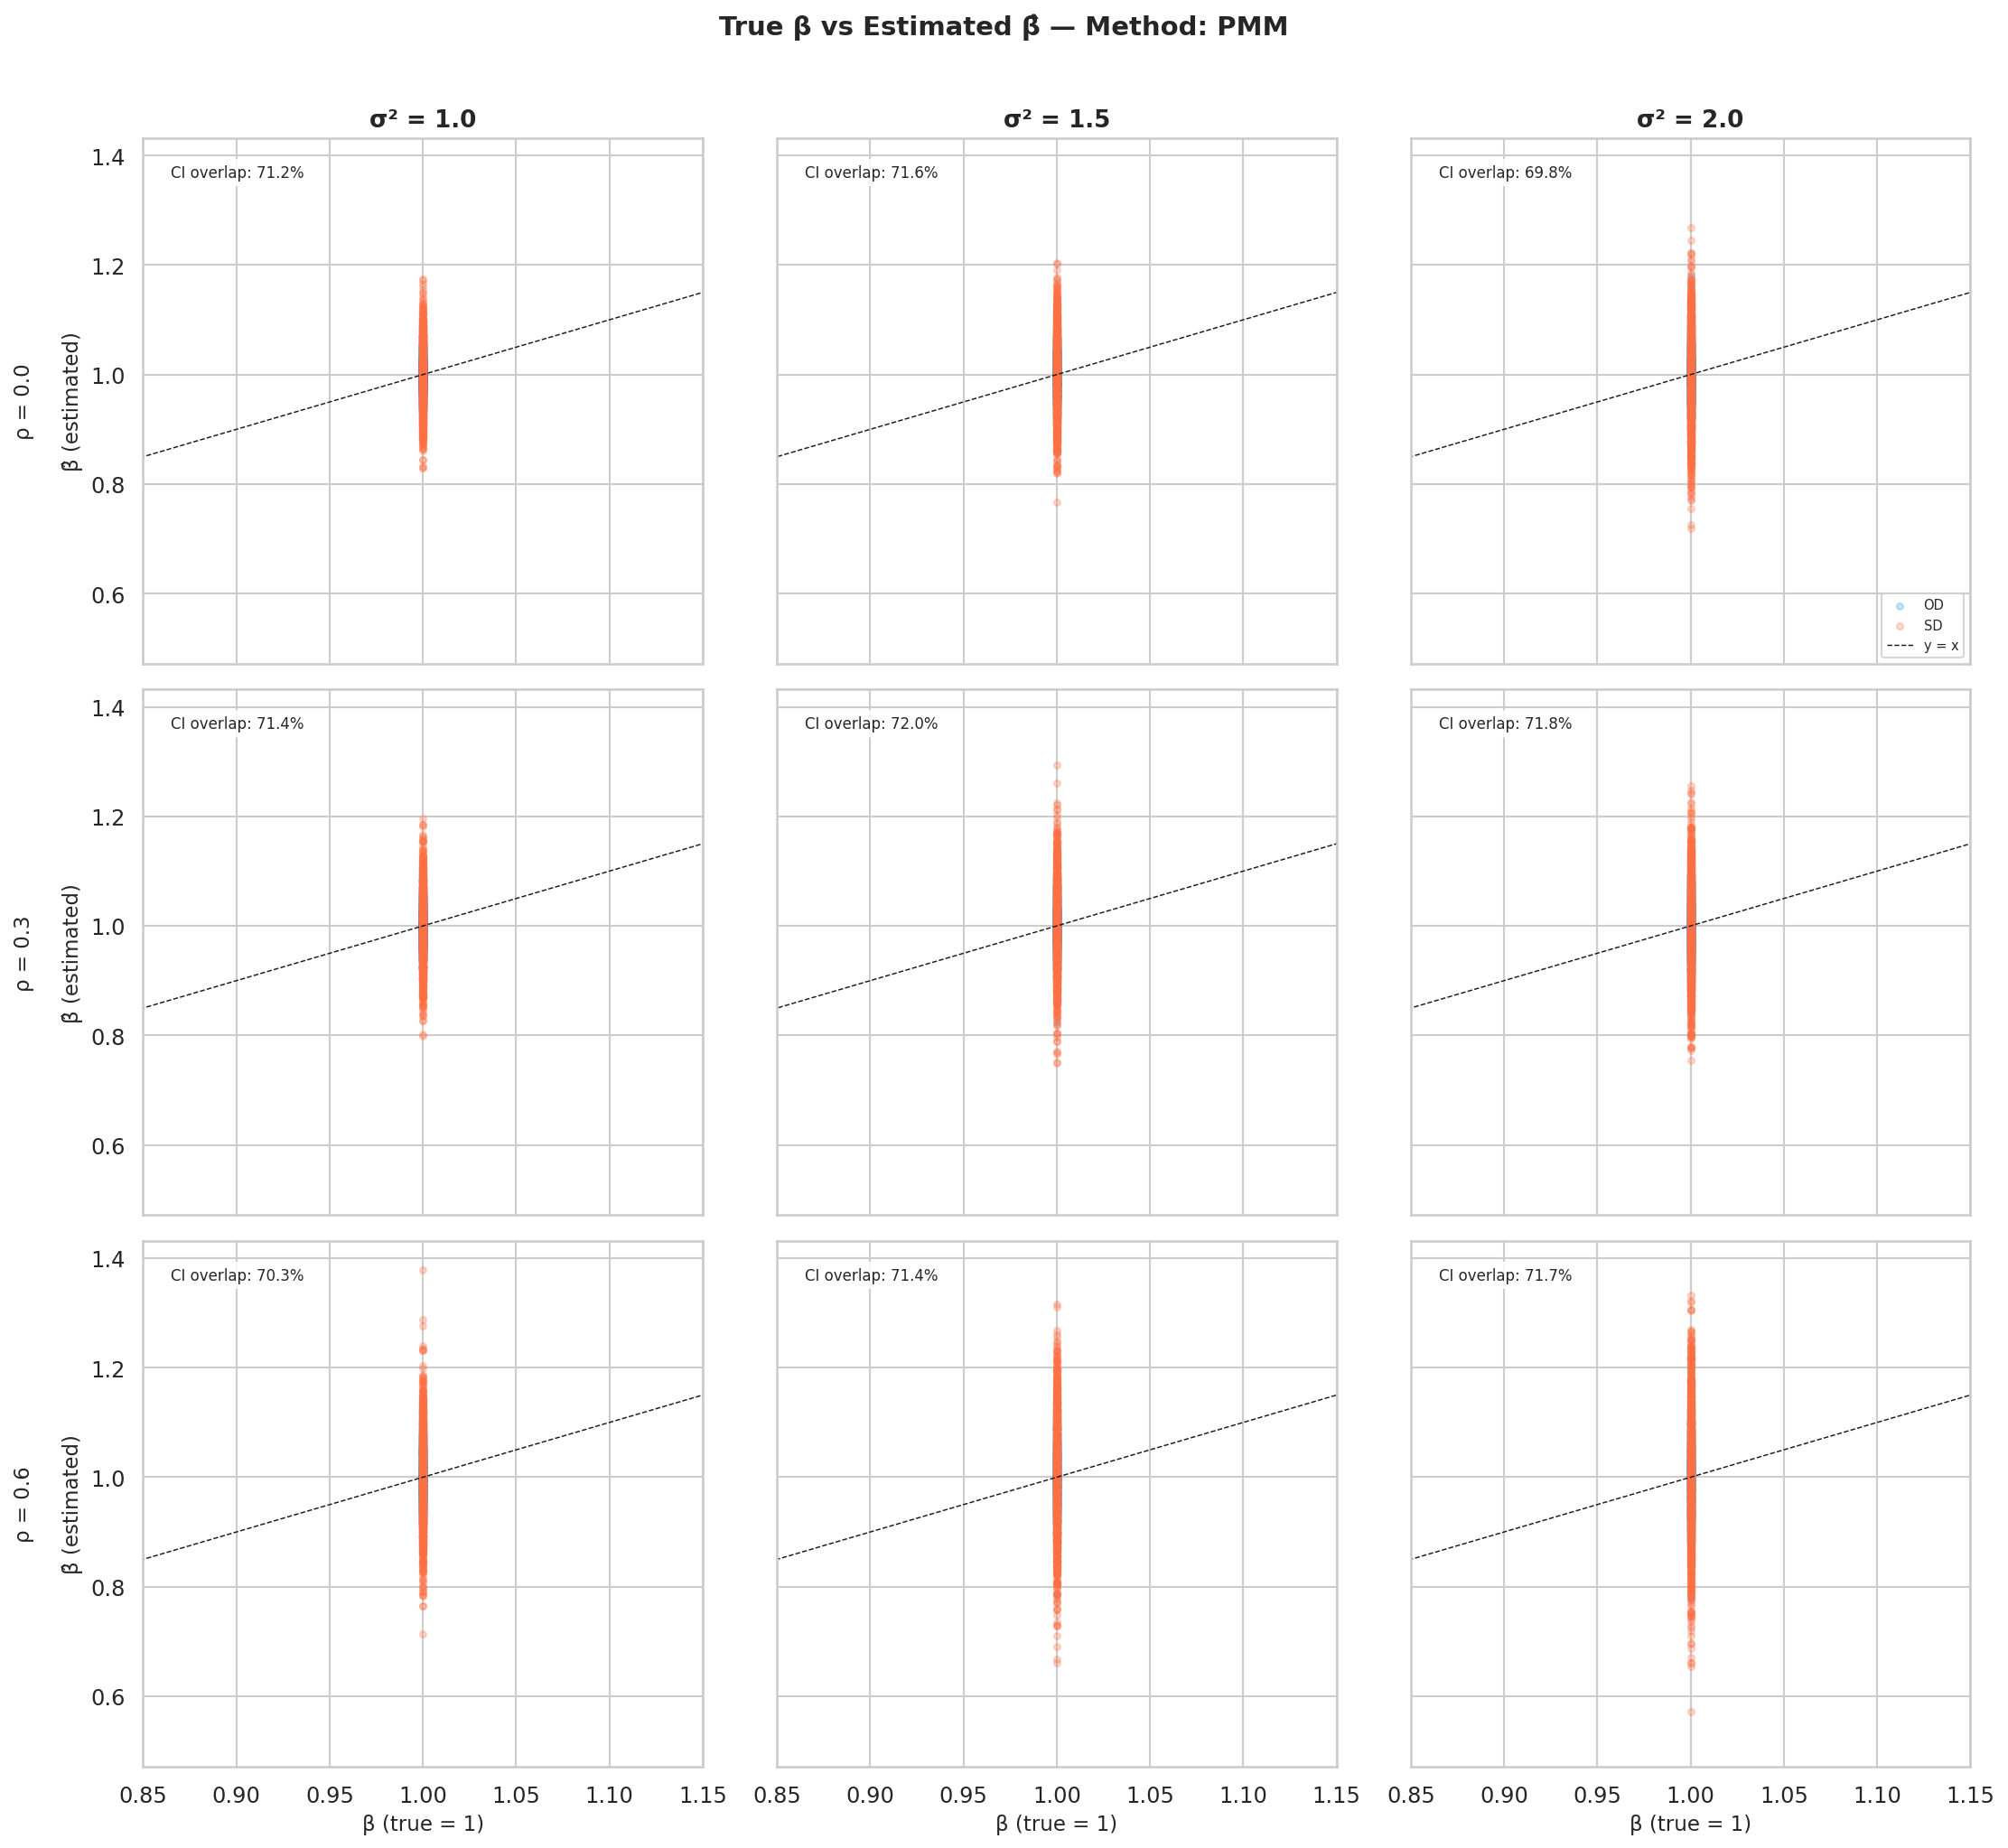

In [36]:
# ── Plot Set A: True β vs Estimated β̂ — per method, 3×3 grid ─────────────
rho_sorted   = sorted(results_df["rho"].unique())
sigma_sorted = sorted(results_df["sigma_2"].unique())

for method in methods:
    fig, axes = plt.subplots(
        len(rho_sorted), len(sigma_sorted),
        figsize=(5 * len(sigma_sorted), 4.5 * len(rho_sorted)),
        sharex=True, sharey=True,
    )

    for ri, rho in enumerate(rho_sorted):
        for si, sigma in enumerate(sigma_sorted):
            ax = axes[ri, si]
            sub = coef_df[
                (coef_df["method"] == method) &
                (coef_df["rho"] == rho) &
                (coef_df["sigma_2"] == sigma)
            ]

            if len(sub) == 0:
                ax.set_visible(False)
                continue

            ax.scatter(sub["beta_true"], sub["beta_od"], alpha=0.25, s=12,
                       color="#2196F3", label="OD")
            ax.scatter(sub["beta_true"], sub["beta_sd"], alpha=0.25, s=12,
                       color="#FF7043", label="SD")

            lims = [sub[["beta_od", "beta_sd"]].min().min() - 0.1,
                    sub[["beta_od", "beta_sd"]].max().max() + 0.1]
            ax.plot(lims, lims, "k--", lw=0.7, label="y = x")
            ax.set_xlim([0.85, 1.15])
            ax.set_ylim(lims)

            # Annotate CI overlap
            ci_val = summary[
                (summary["method"] == method) &
                (summary["rho"] == rho) &
                (summary["sigma_2"] == sigma)
            ]["ci_overlap_mean"].values
            if len(ci_val) > 0:
                ax.text(0.05, 0.95, f"CI overlap: {ci_val[0]:.1f}%",
                        transform=ax.transAxes, fontsize=8, va="top",
                        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

            if ri == 0:
                ax.set_title(f"σ² = {sigma}")
            if si == 0:
                ax.set_ylabel(f"ρ = {rho}\n\nβ̂ (estimated)")
            if ri == len(rho_sorted) - 1:
                ax.set_xlabel("β (true = 1)")
            if ri == 0 and si == len(sigma_sorted) - 1:
                ax.legend(fontsize=7, loc="lower right")

    fig.suptitle(f"True β vs Estimated β̂ — Method: {method.upper()}",
                 fontweight="bold", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(result_dir, f"plot_scatter_grid_{method}.png"),
                dpi=200, bbox_inches="tight")
    plt.show()

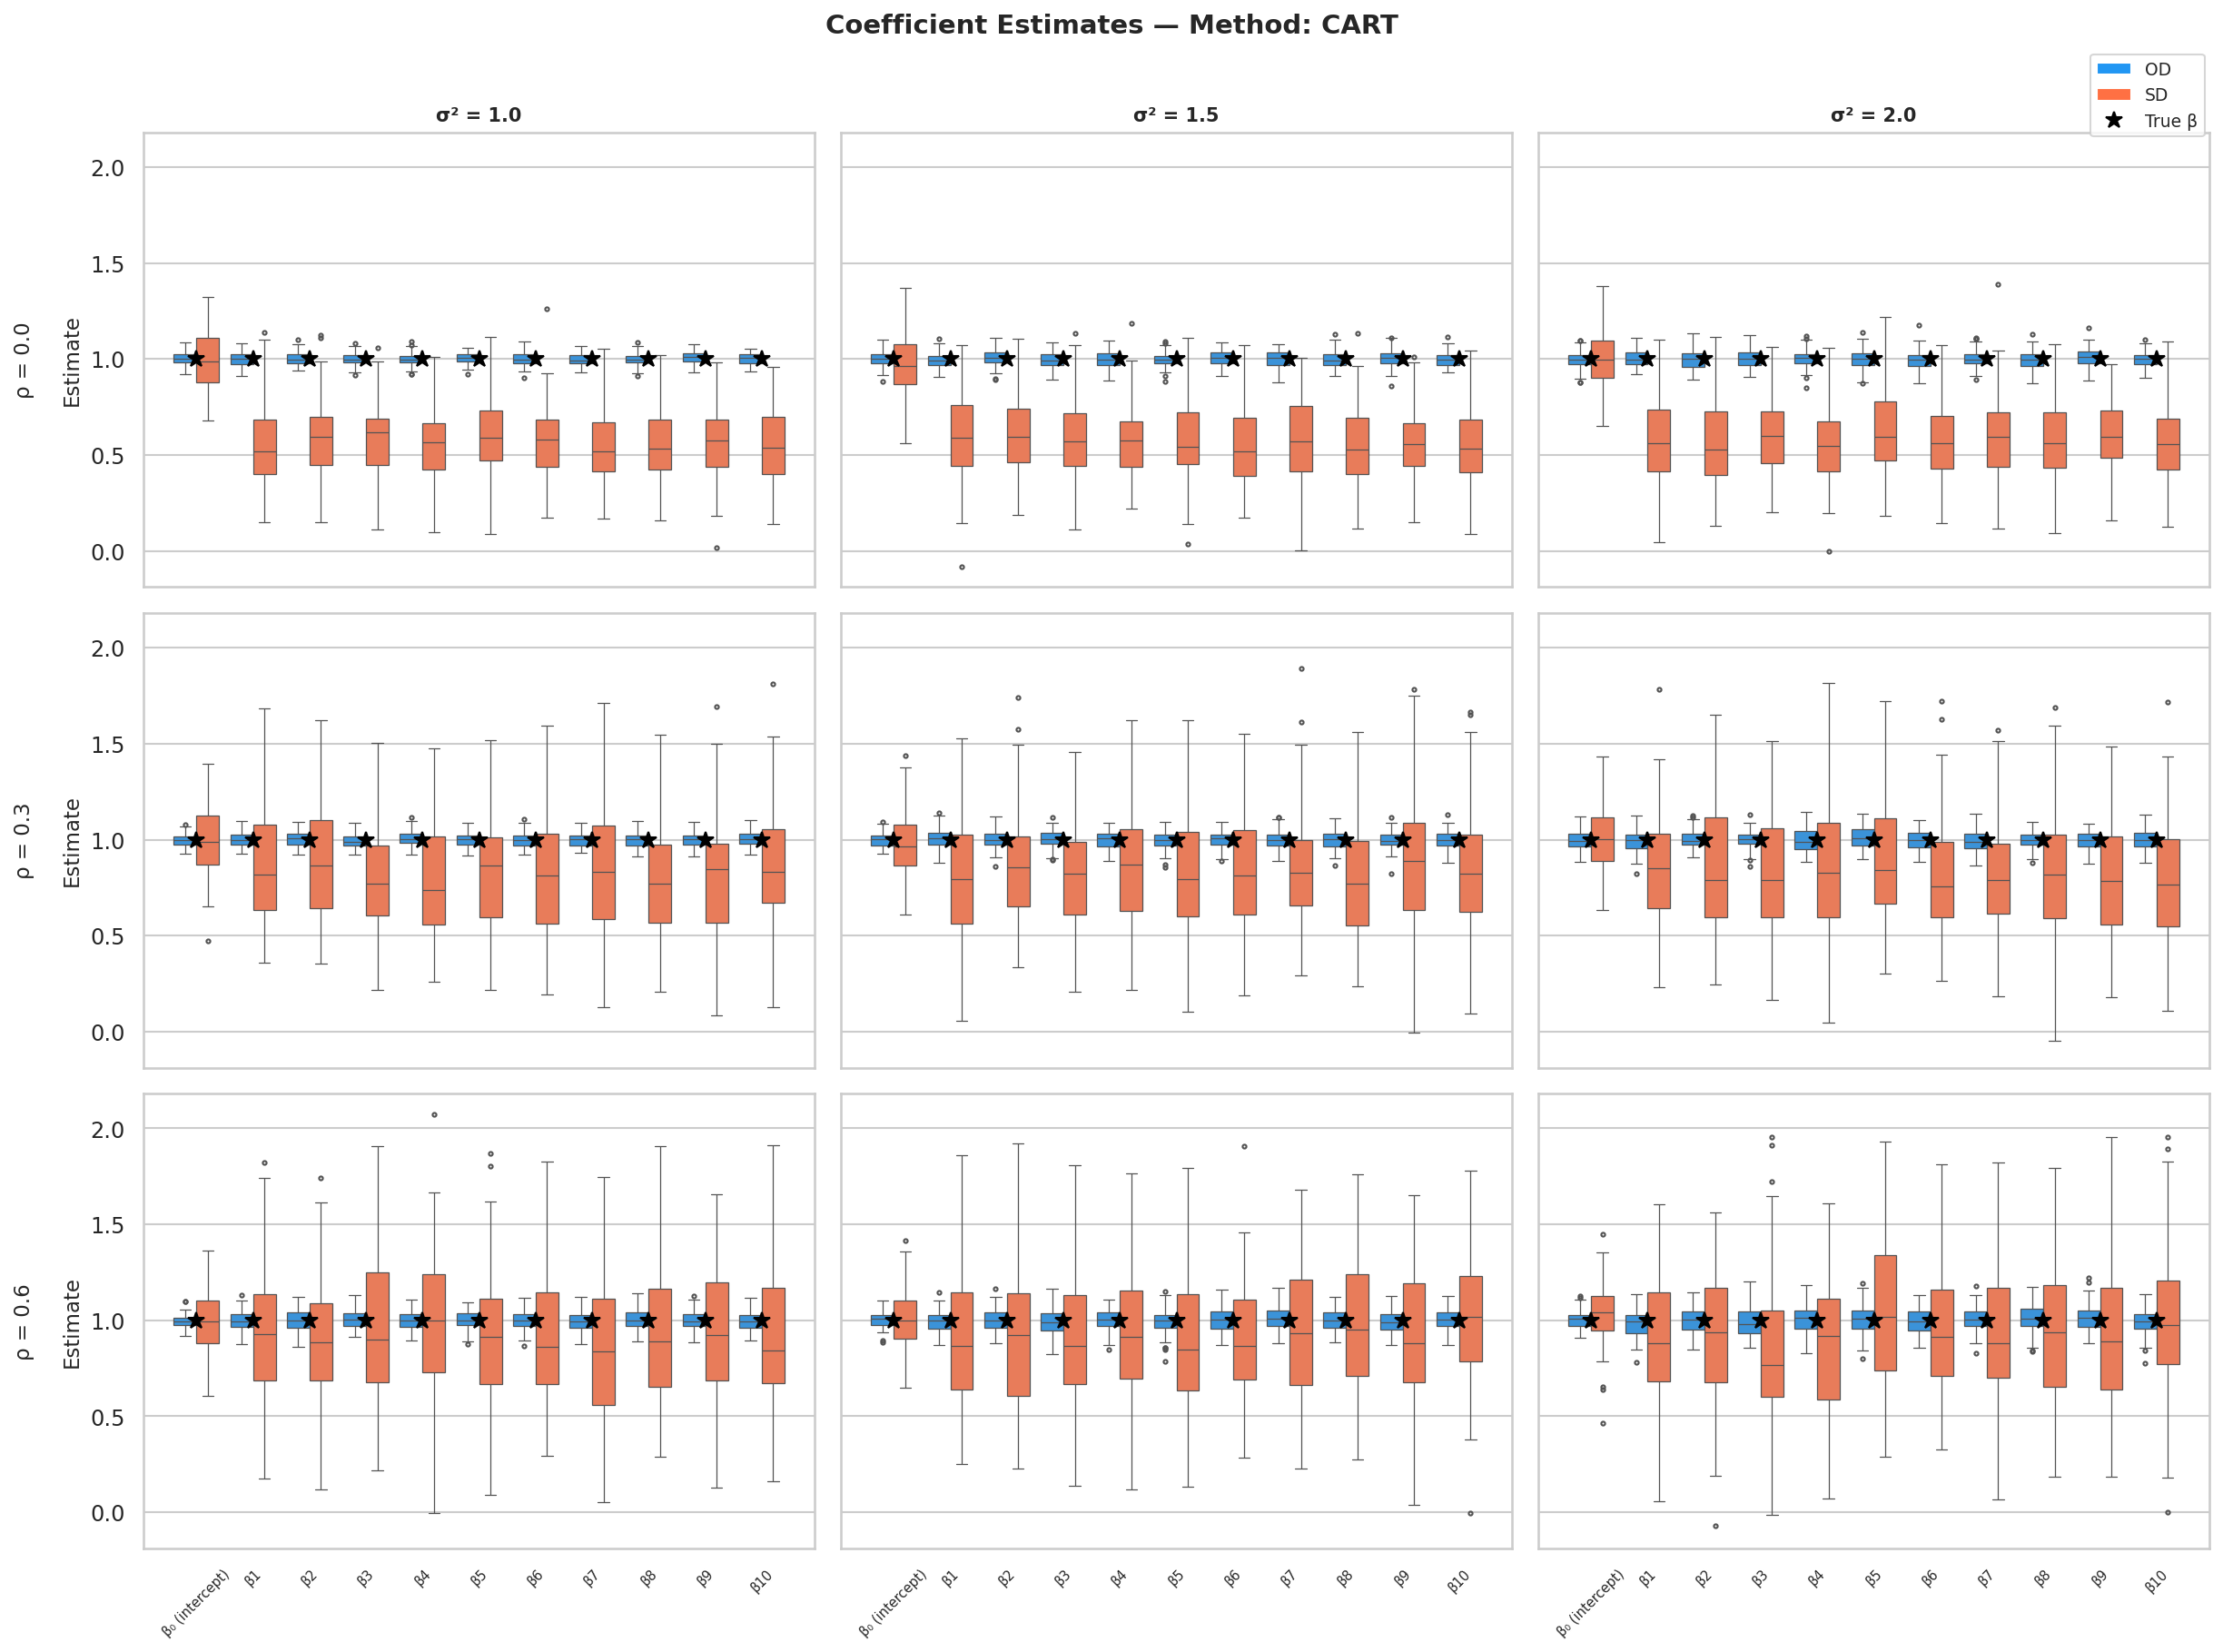

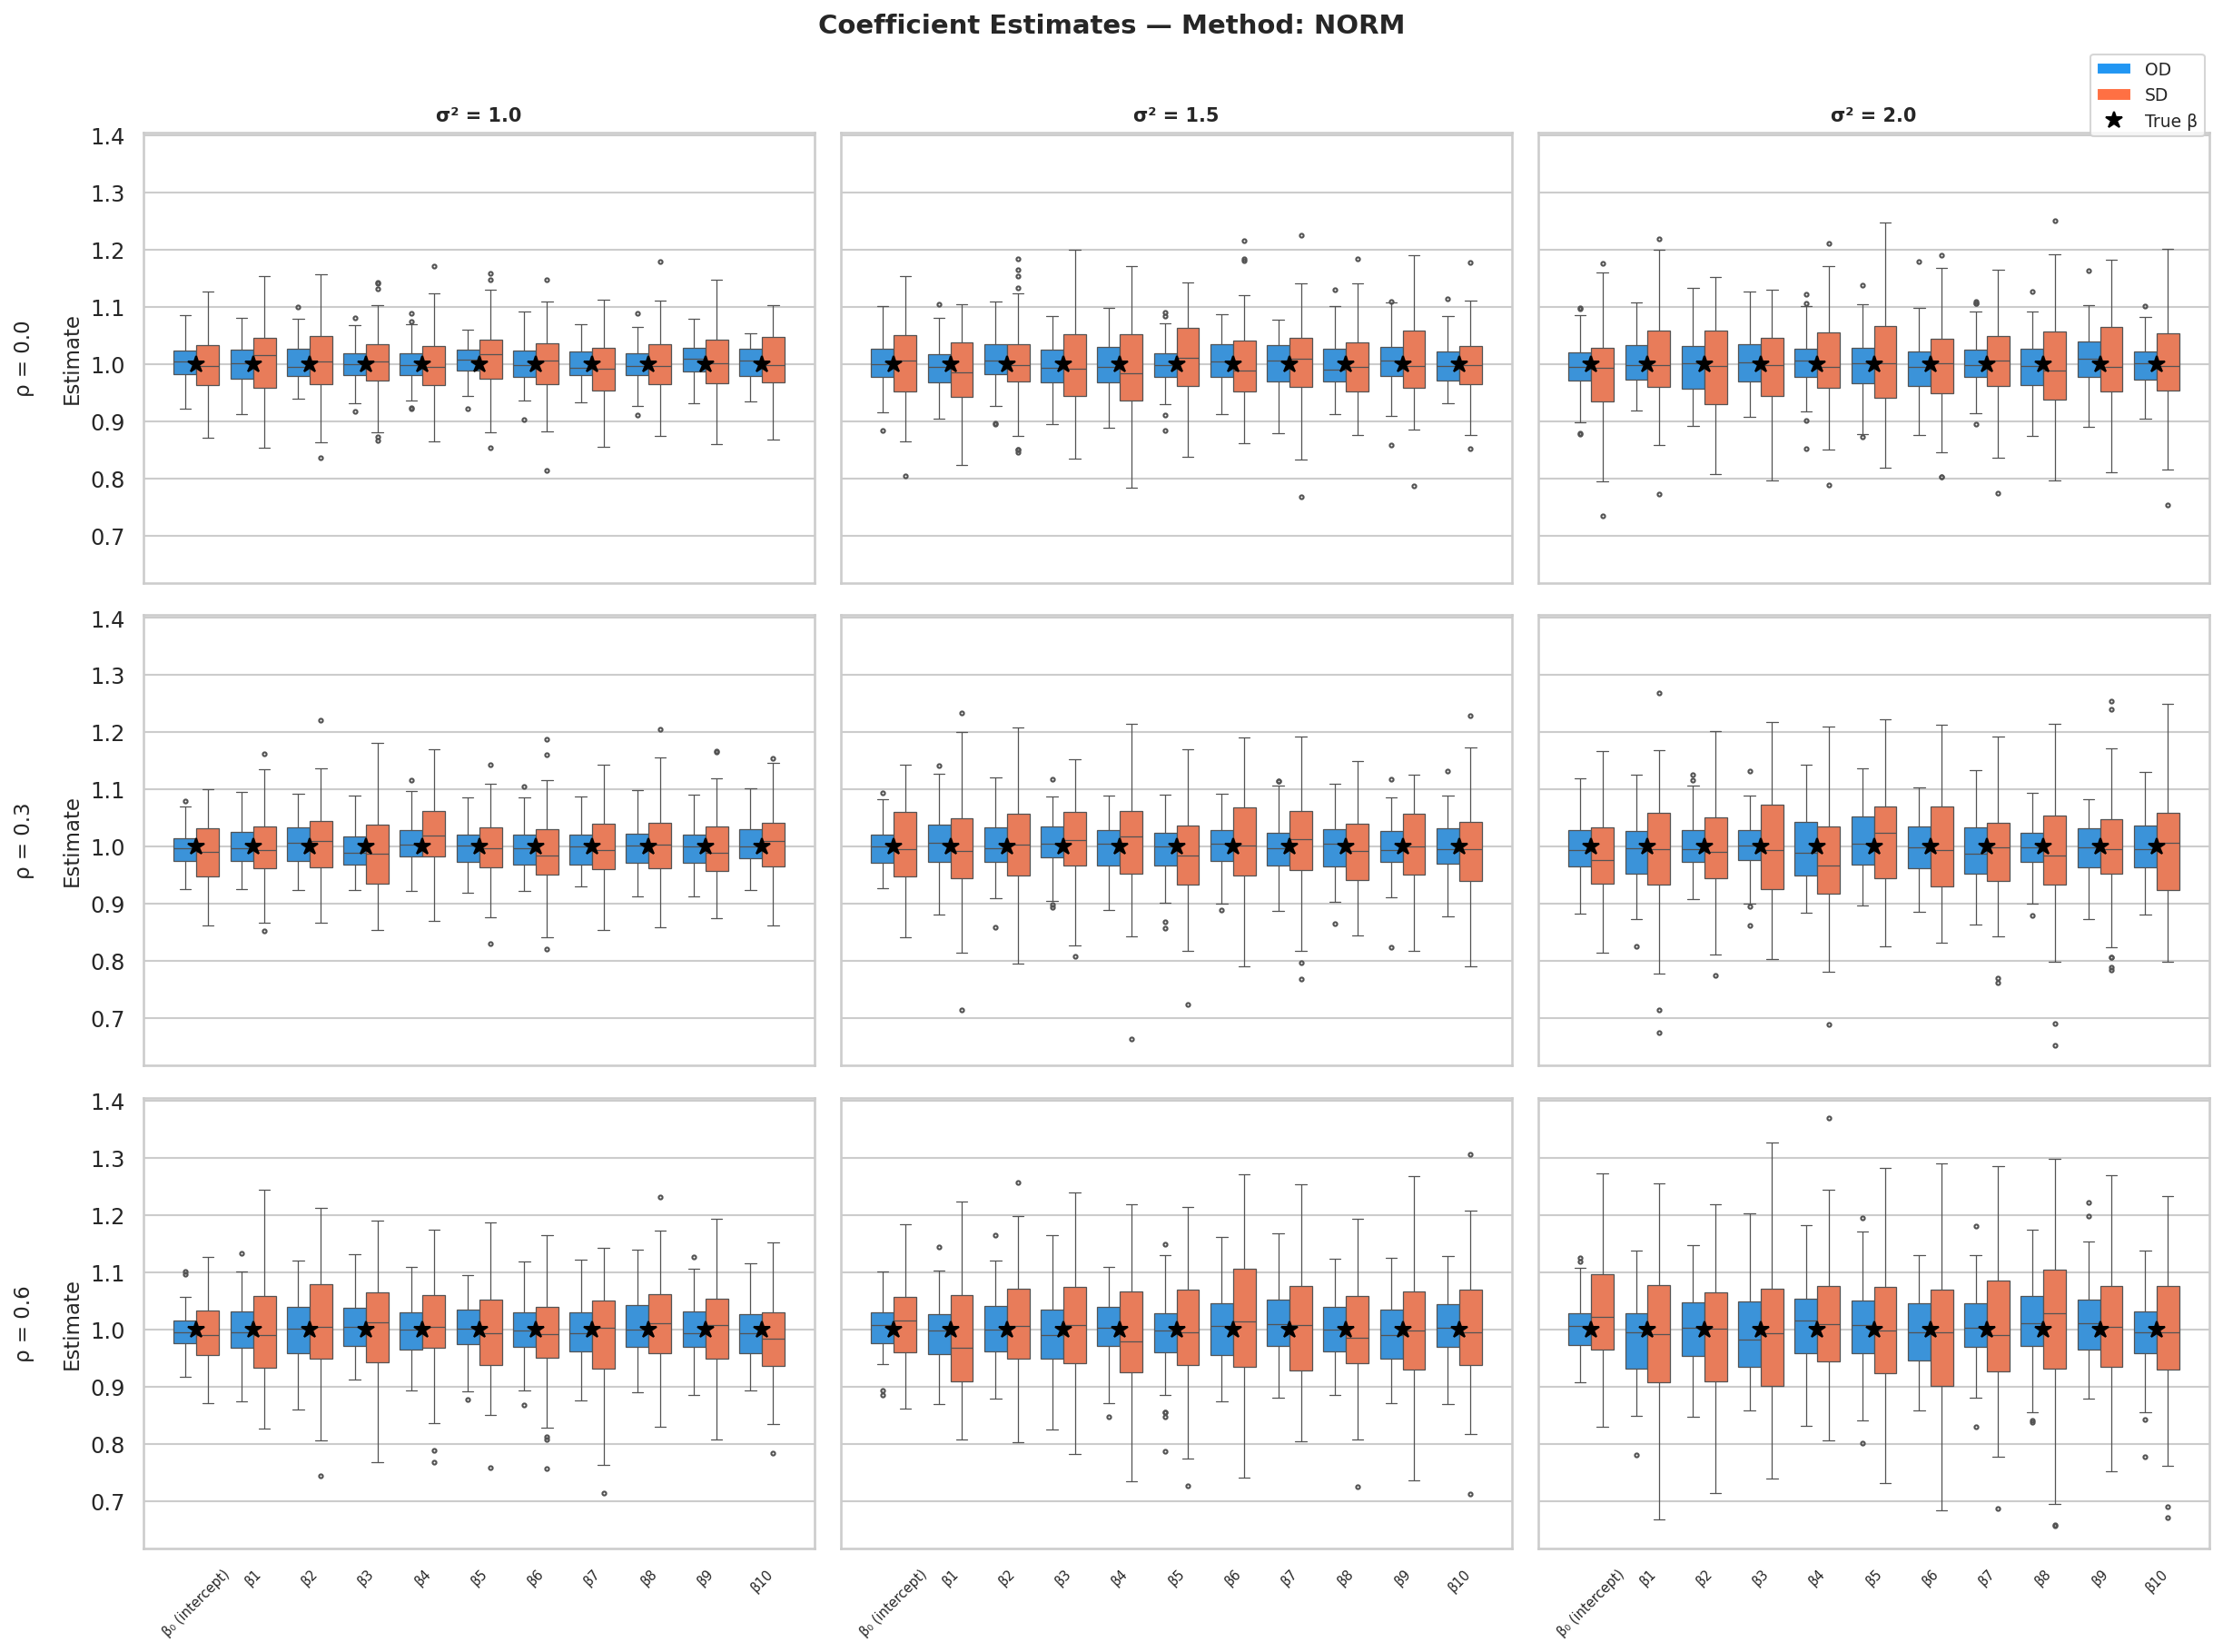

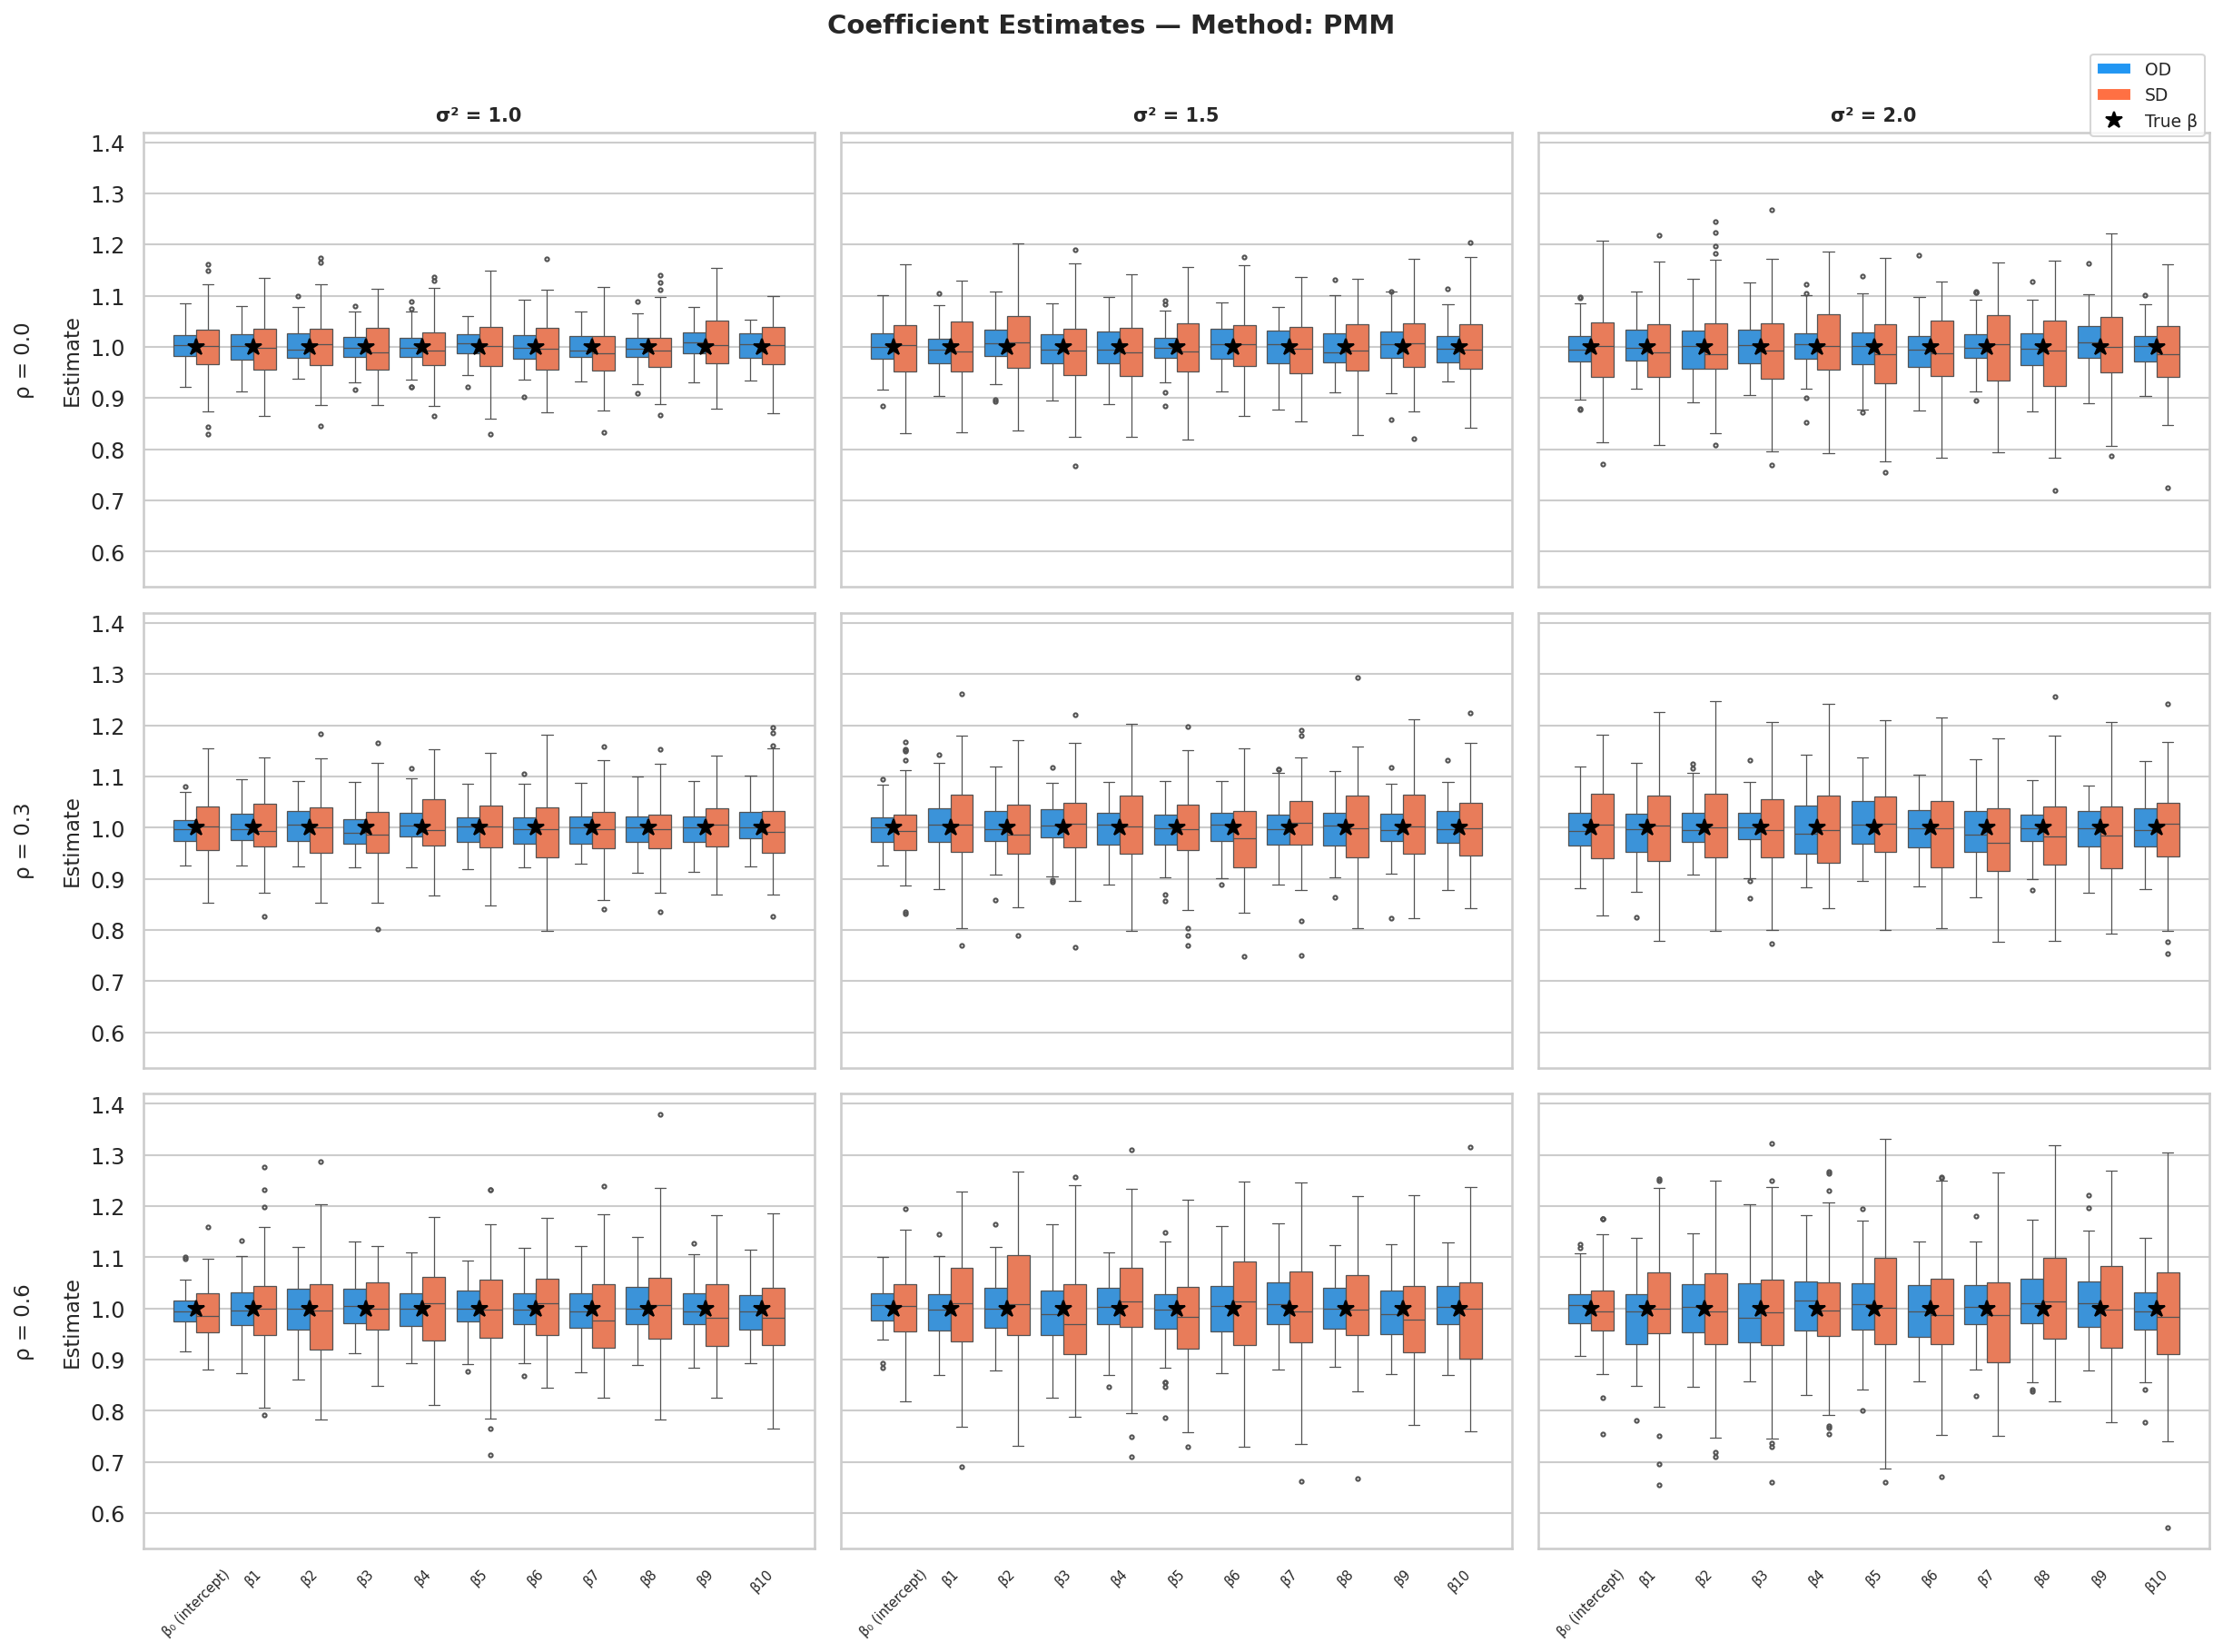

In [37]:
# ── Plot Set B: Coefficient Box Plots — per method, 3×3 grid ──────────────
palette = {"OD": "#2196F3", "SD": "#FF7043"}

for method in methods:
    fig, axes = plt.subplots(
        len(rho_sorted), len(sigma_sorted),
        figsize=(5.5 * len(sigma_sorted), 4 * len(rho_sorted)),
        sharex=True, sharey=True,
    )

    for ri, rho in enumerate(rho_sorted):
        for si, sigma in enumerate(sigma_sorted):
            ax = axes[ri, si]
            sub = coef_df[
                (coef_df["method"] == method) &
                (coef_df["rho"] == rho) &
                (coef_df["sigma_2"] == sigma)
            ].copy()

            if len(sub) == 0:
                ax.set_visible(False)
                continue

            sub_long = pd.melt(
                sub, id_vars=["rep", "term", "beta_true"],
                value_vars=["beta_od", "beta_sd"],
                var_name="source", value_name="Estimate",
            )
            sub_long["source"] = sub_long["source"].map({"beta_od": "OD", "beta_sd": "SD"})

            sns.boxplot(
                data=sub_long, x="term", y="Estimate", hue="source",
                palette=palette, ax=ax, linewidth=0.6, fliersize=2,
            )

            # True values
            true_vals = sub.drop_duplicates("term").set_index("term")["beta_true"]
            for k, term in enumerate(sub["term"].unique()):
                ax.plot(k, true_vals[term], marker="*", color="black",
                        markersize=9, zorder=5)

            ax.get_legend().remove() if ax.get_legend() else None
            ax.tick_params(axis="x", rotation=45, labelsize=7)

            if ri == 0:
                ax.set_title(f"σ² = {sigma}", fontsize=10)
            if si == 0:
                ax.set_ylabel(f"ρ = {rho}\n\nEstimate")
            else:
                ax.set_ylabel("")
            ax.set_xlabel("")

    # Shared legend
    handles = [
        plt.Rectangle((0,0),1,1, fc="#2196F3", label="OD"),
        plt.Rectangle((0,0),1,1, fc="#FF7043", label="SD"),
        Line2D([0],[0], marker="*", color="black", ls="", markersize=9, label="True β"),
    ]
    fig.legend(handles=handles, loc="upper right", fontsize=9,
               bbox_to_anchor=(0.99, 0.99))

    fig.suptitle(f"Coefficient Estimates — Method: {method.upper()}",
                 fontweight="bold", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(result_dir, f"plot_coef_boxplot_grid_{method}.png"),
                dpi=200, bbox_inches="tight")
    plt.show()

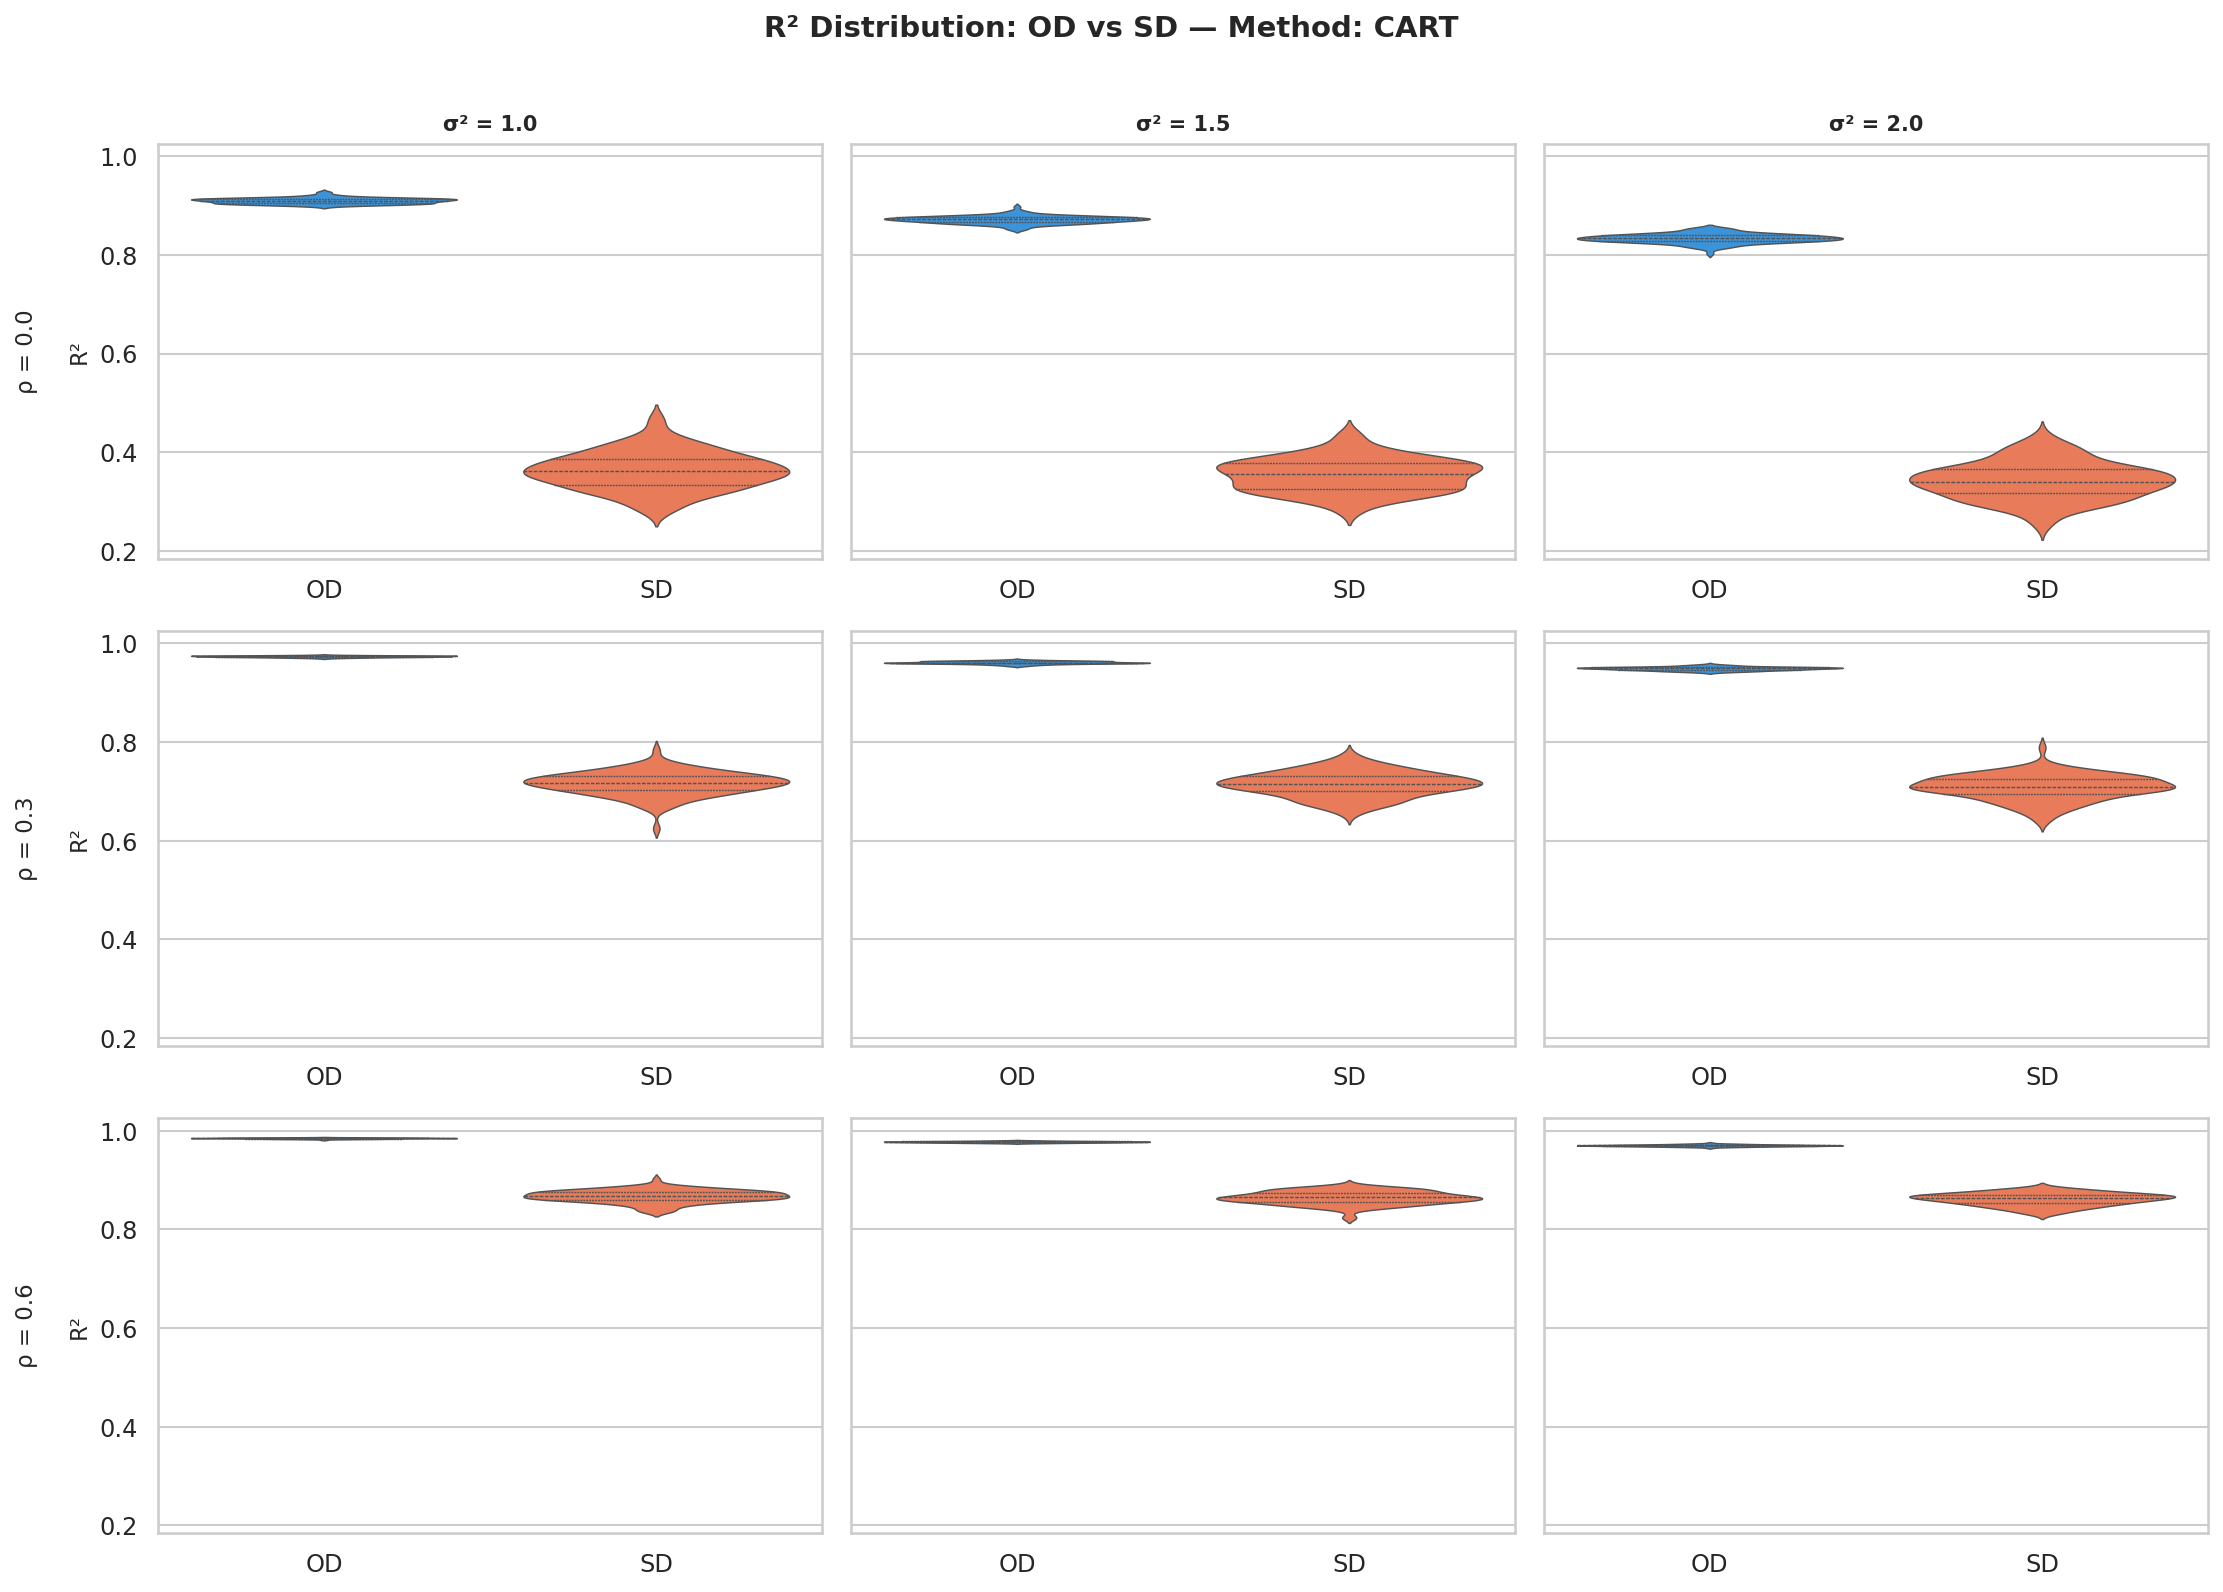

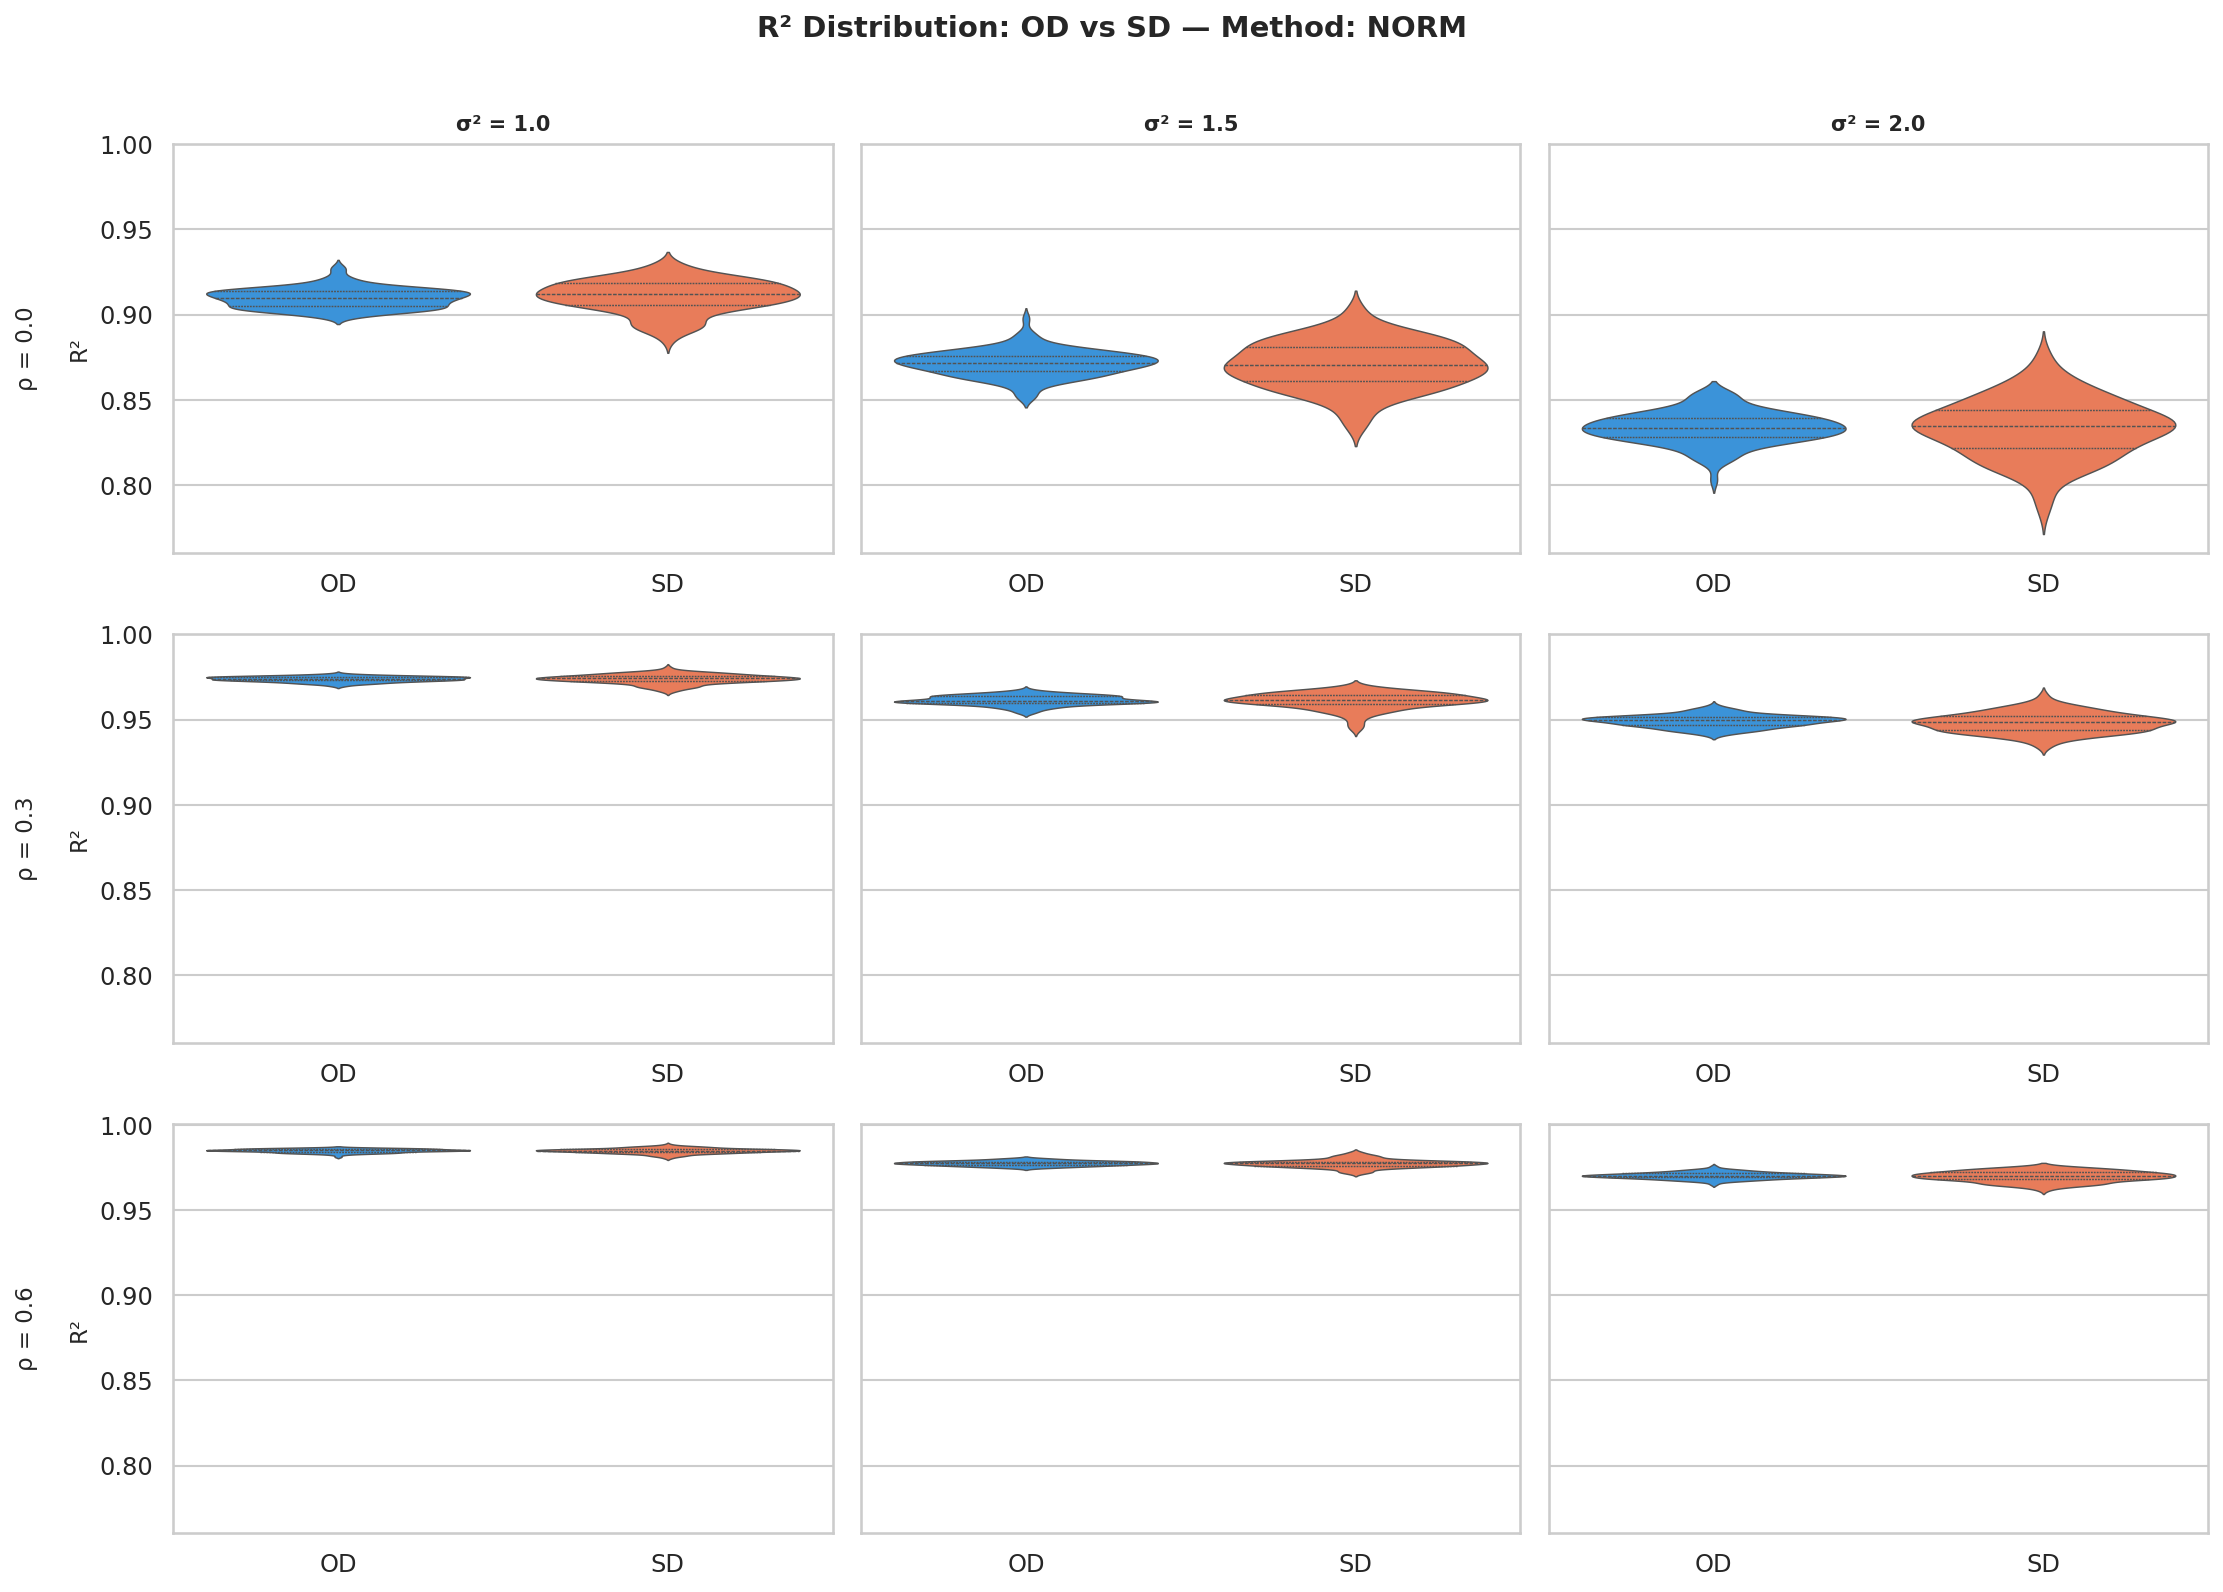

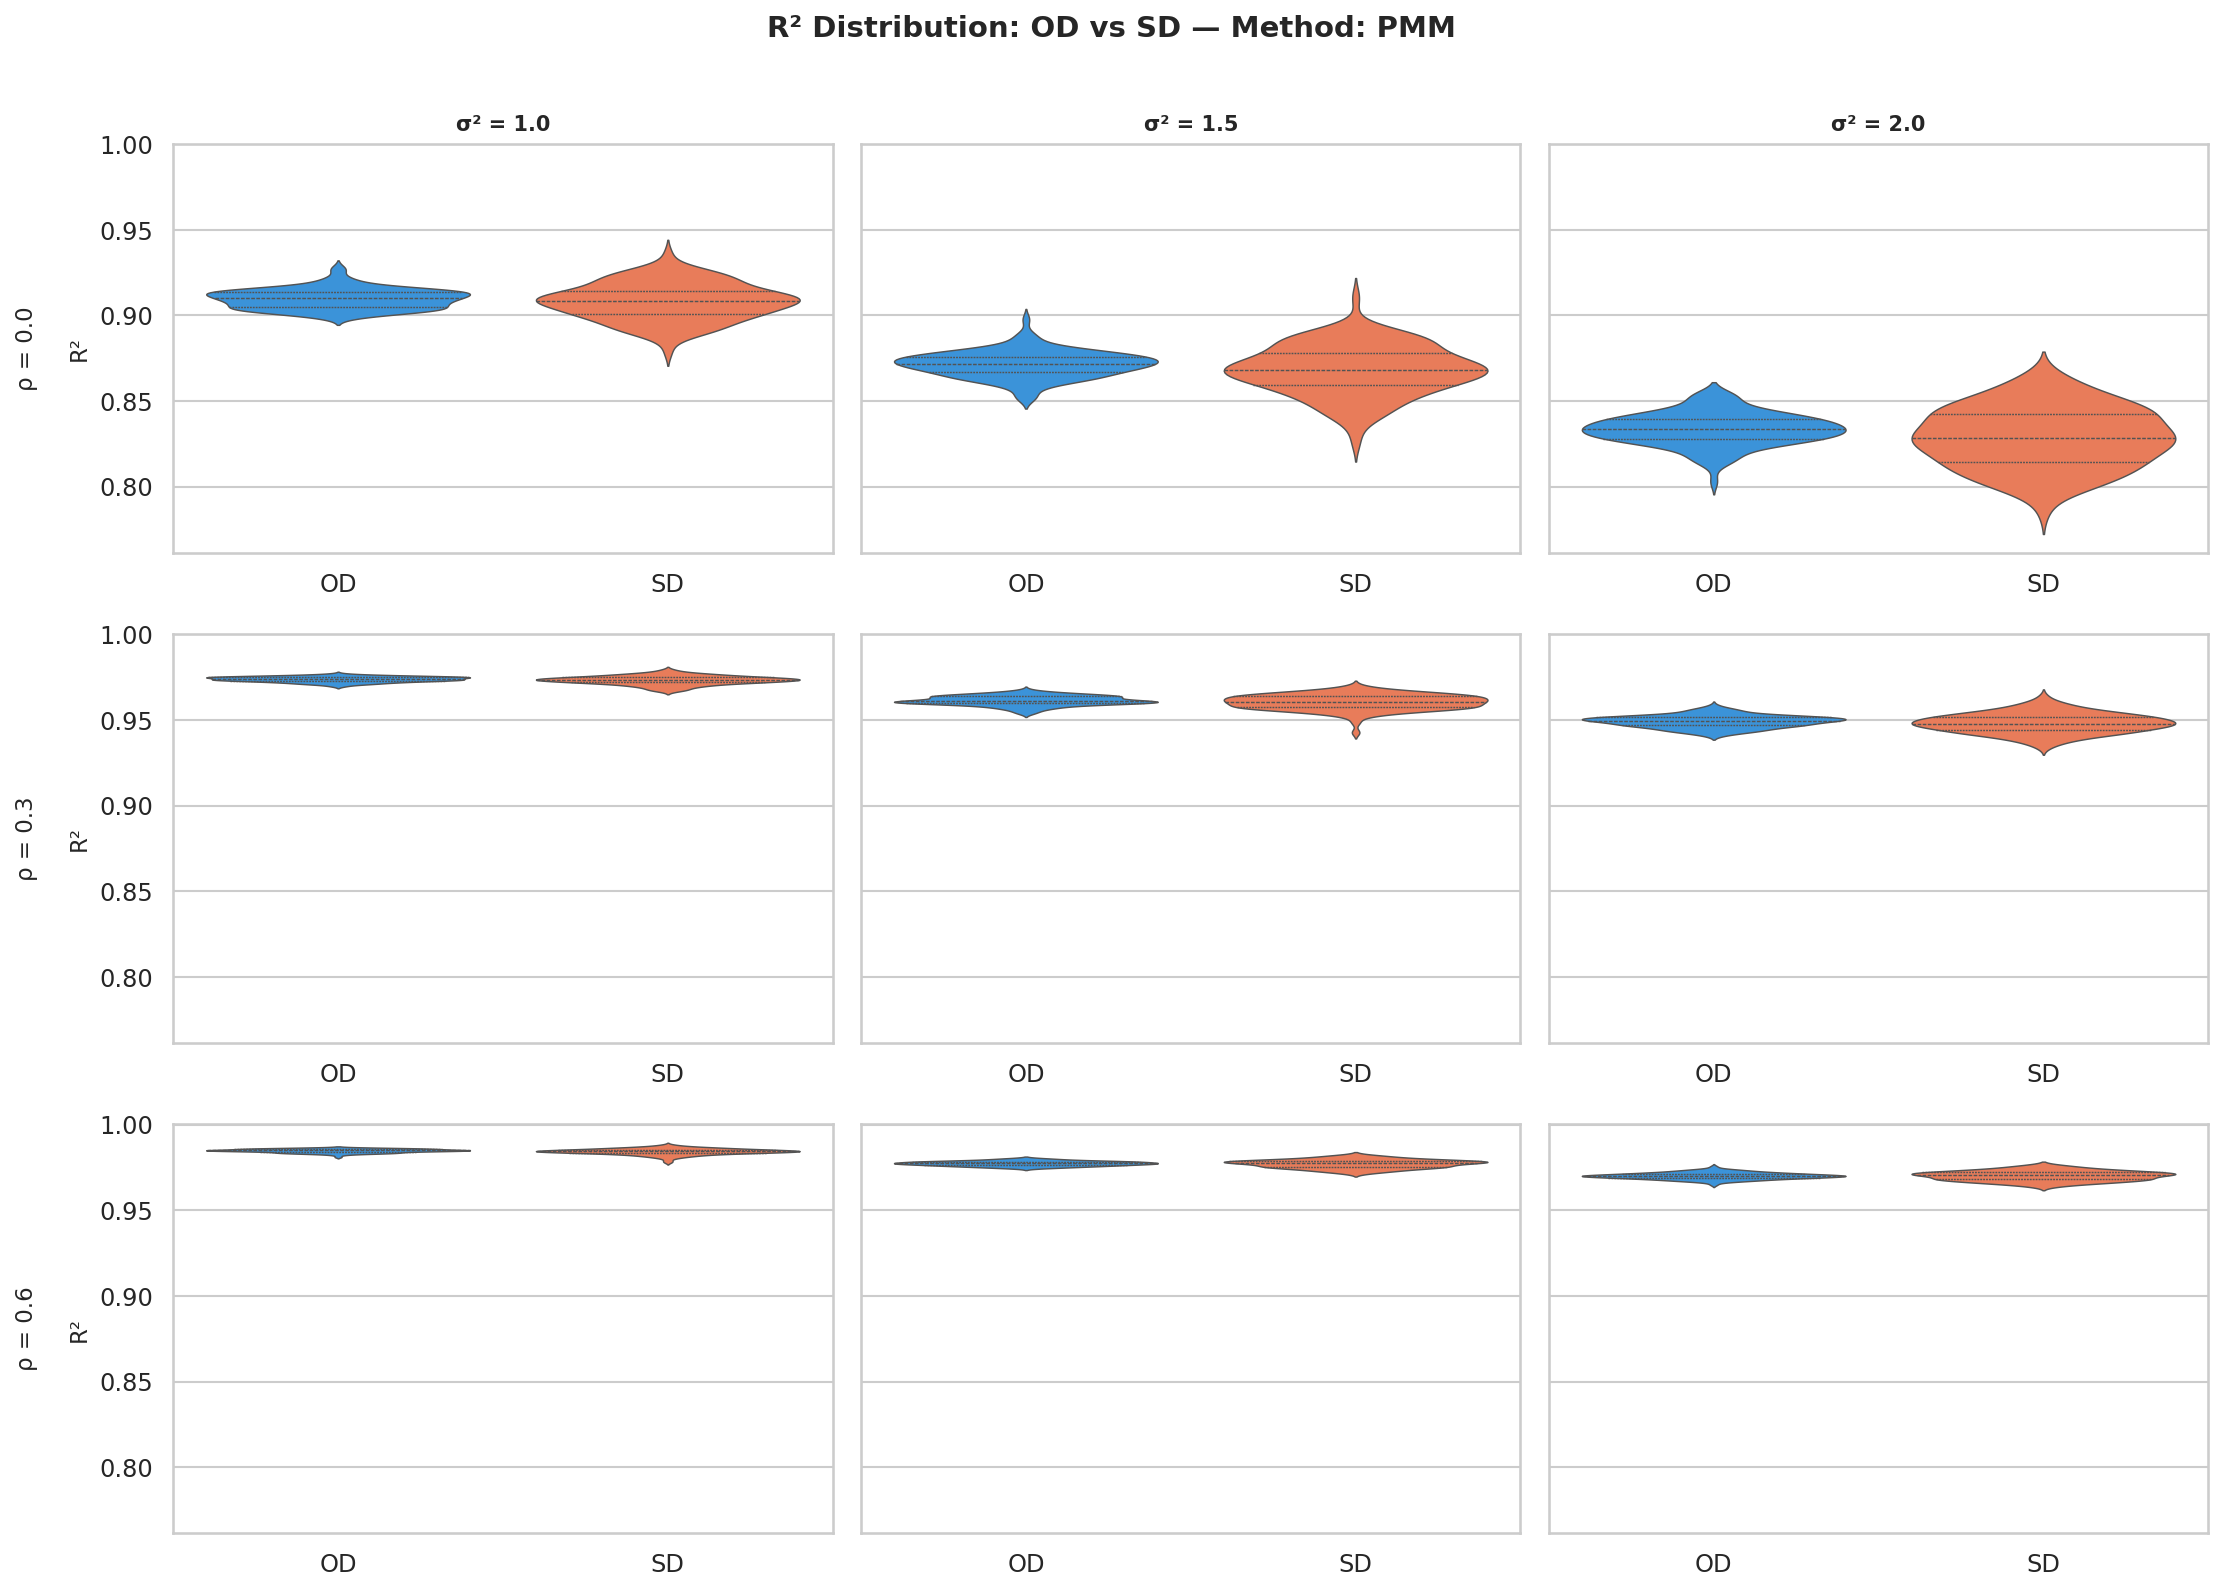

In [38]:
# ── Plot Set C: R² Distribution — per method, 3×3 grid ────────────────────
for method in methods:
    fig, axes = plt.subplots(
        len(rho_sorted), len(sigma_sorted),
        figsize=(5 * len(sigma_sorted), 3.5 * len(rho_sorted)),
        sharex=False, sharey=True,
    )

    for ri, rho in enumerate(rho_sorted):
        for si, sigma in enumerate(sigma_sorted):
            ax = axes[ri, si]
            sub = results_df[
                (results_df["method"] == method) &
                (results_df["rho"] == rho) &
                (results_df["sigma_2"] == sigma)
            ]

            if len(sub) == 0:
                ax.set_visible(False)
                continue

            sub_long = pd.melt(
                sub, id_vars=["rep"],
                value_vars=["r2_od", "r2_sd"],
                var_name="source", value_name="R²",
            )
            sub_long["source"] = sub_long["source"].map({"r2_od": "OD", "r2_sd": "SD"})

            sns.violinplot(
                data=sub_long, x="source", y="R²", hue="source",
                palette=palette, inner="quart", ax=ax, linewidth=0.7,
                legend=False,
            )

            if ri == 0:
                ax.set_title(f"σ² = {sigma}", fontsize=10)
            if si == 0:
                ax.set_ylabel(f"ρ = {rho}\n\nR²")
            else:
                ax.set_ylabel("")
            ax.set_xlabel("")

    fig.suptitle(f"R² Distribution: OD vs SD — Method: {method.upper()}",
                 fontweight="bold", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(result_dir, f"plot_r2_grid_{method}.png"),
                dpi=200, bbox_inches="tight")
    plt.show()

## Cross-Method Comparison

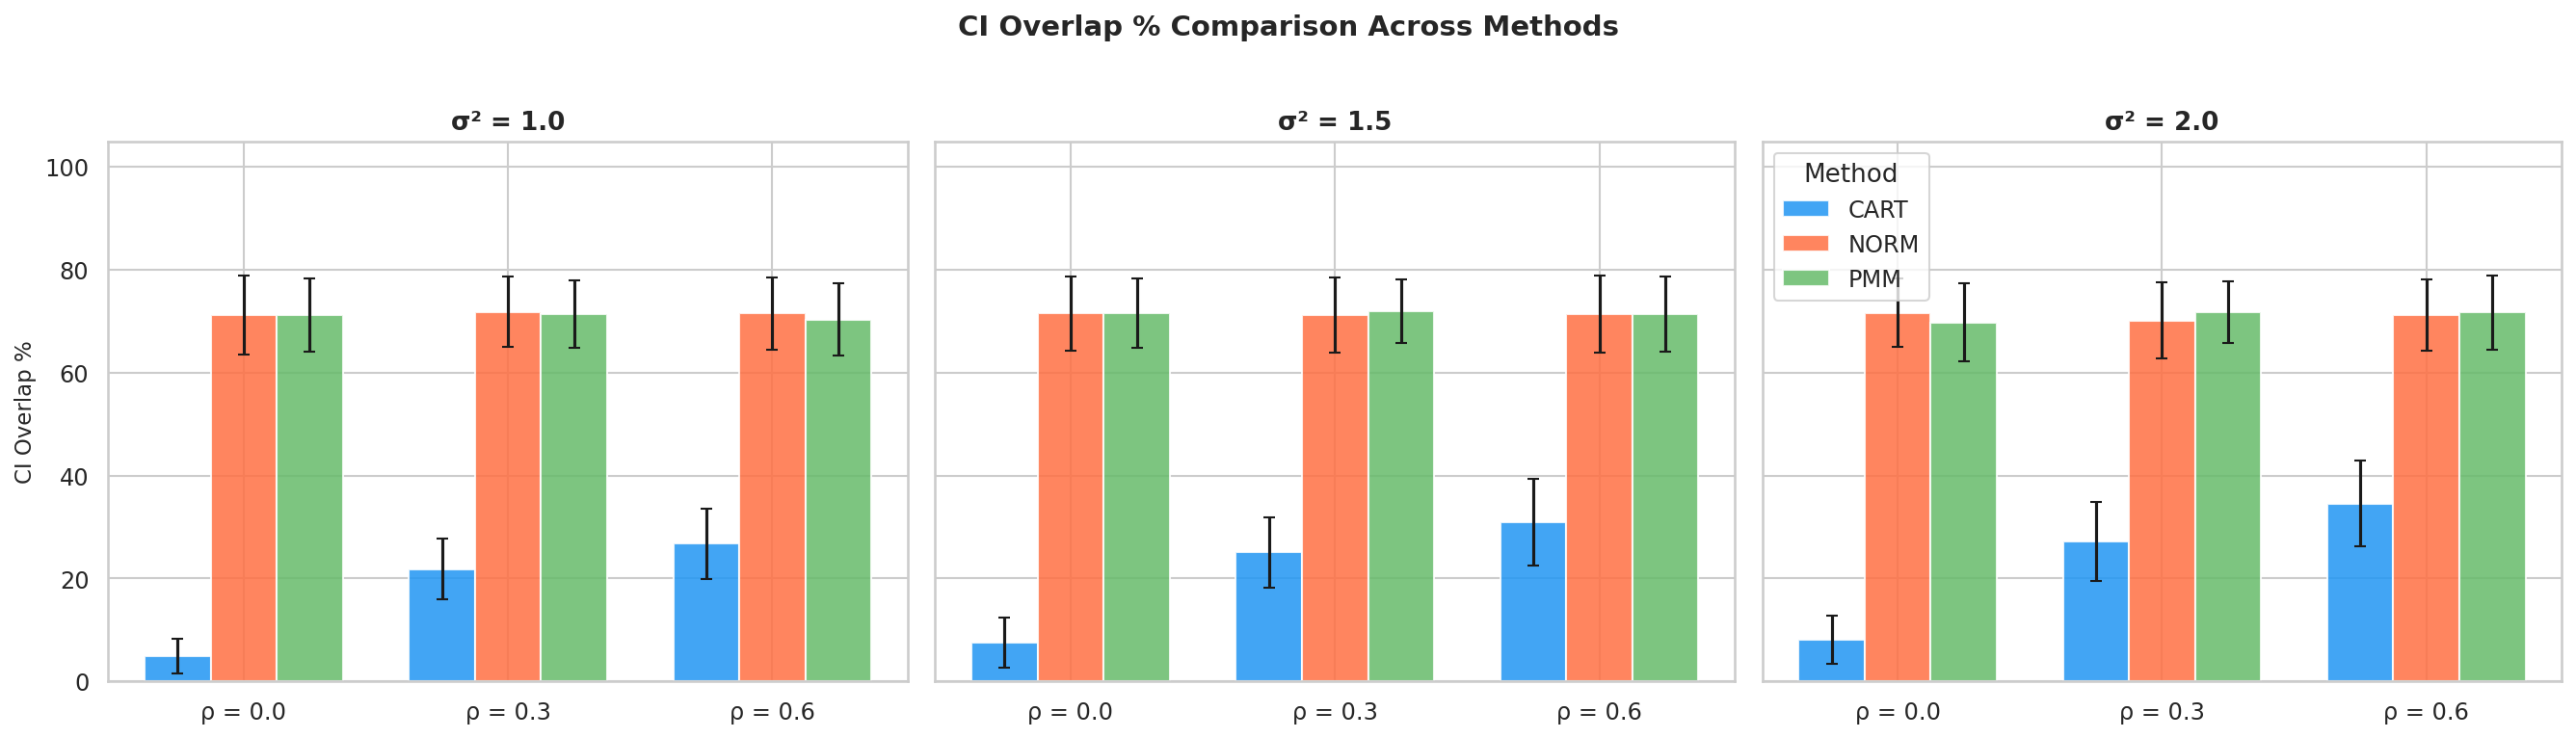

In [39]:
# ── Plot: CI Overlap comparison across methods (grouped bar) ───────────────
# One panel per sigma_2

fig, axes = plt.subplots(1, len(sigma_sorted), figsize=(6 * len(sigma_sorted), 5),
                         sharey=True)
if len(sigma_sorted) == 1:
    axes = [axes]

method_colors = {"cart": "#2196F3", "norm": "#FF7043", "pmm": "#66BB6A"}

for ax, sigma in zip(axes, sigma_sorted):
    sub = summary[summary["sigma_2"] == sigma]
    x = np.arange(len(rho_sorted))
    width = 0.25

    for mi, method in enumerate(methods):
        msub = sub[sub["method"] == method]
        ax.bar(
            x + mi * width, msub["ci_overlap_mean"].values,
            width, yerr=msub["ci_overlap_std"].values,
            label=method.upper(), color=method_colors[method],
            edgecolor="white", capsize=3, alpha=0.85,
        )

    ax.set_xticks(x + width)
    ax.set_xticklabels([f"ρ = {r}" for r in rho_sorted])
    ax.set_title(f"σ² = {sigma}")
    ax.set_ylabel("CI Overlap %" if ax == axes[0] else "")
    ax.set_ylim(0, 105)
    if ax == axes[-1]:
        ax.legend(title="Method")

plt.suptitle("CI Overlap % Comparison Across Methods",
             fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(result_dir, "plot_ci_overlap_comparison.png"),
            dpi=200, bbox_inches="tight")
plt.show()

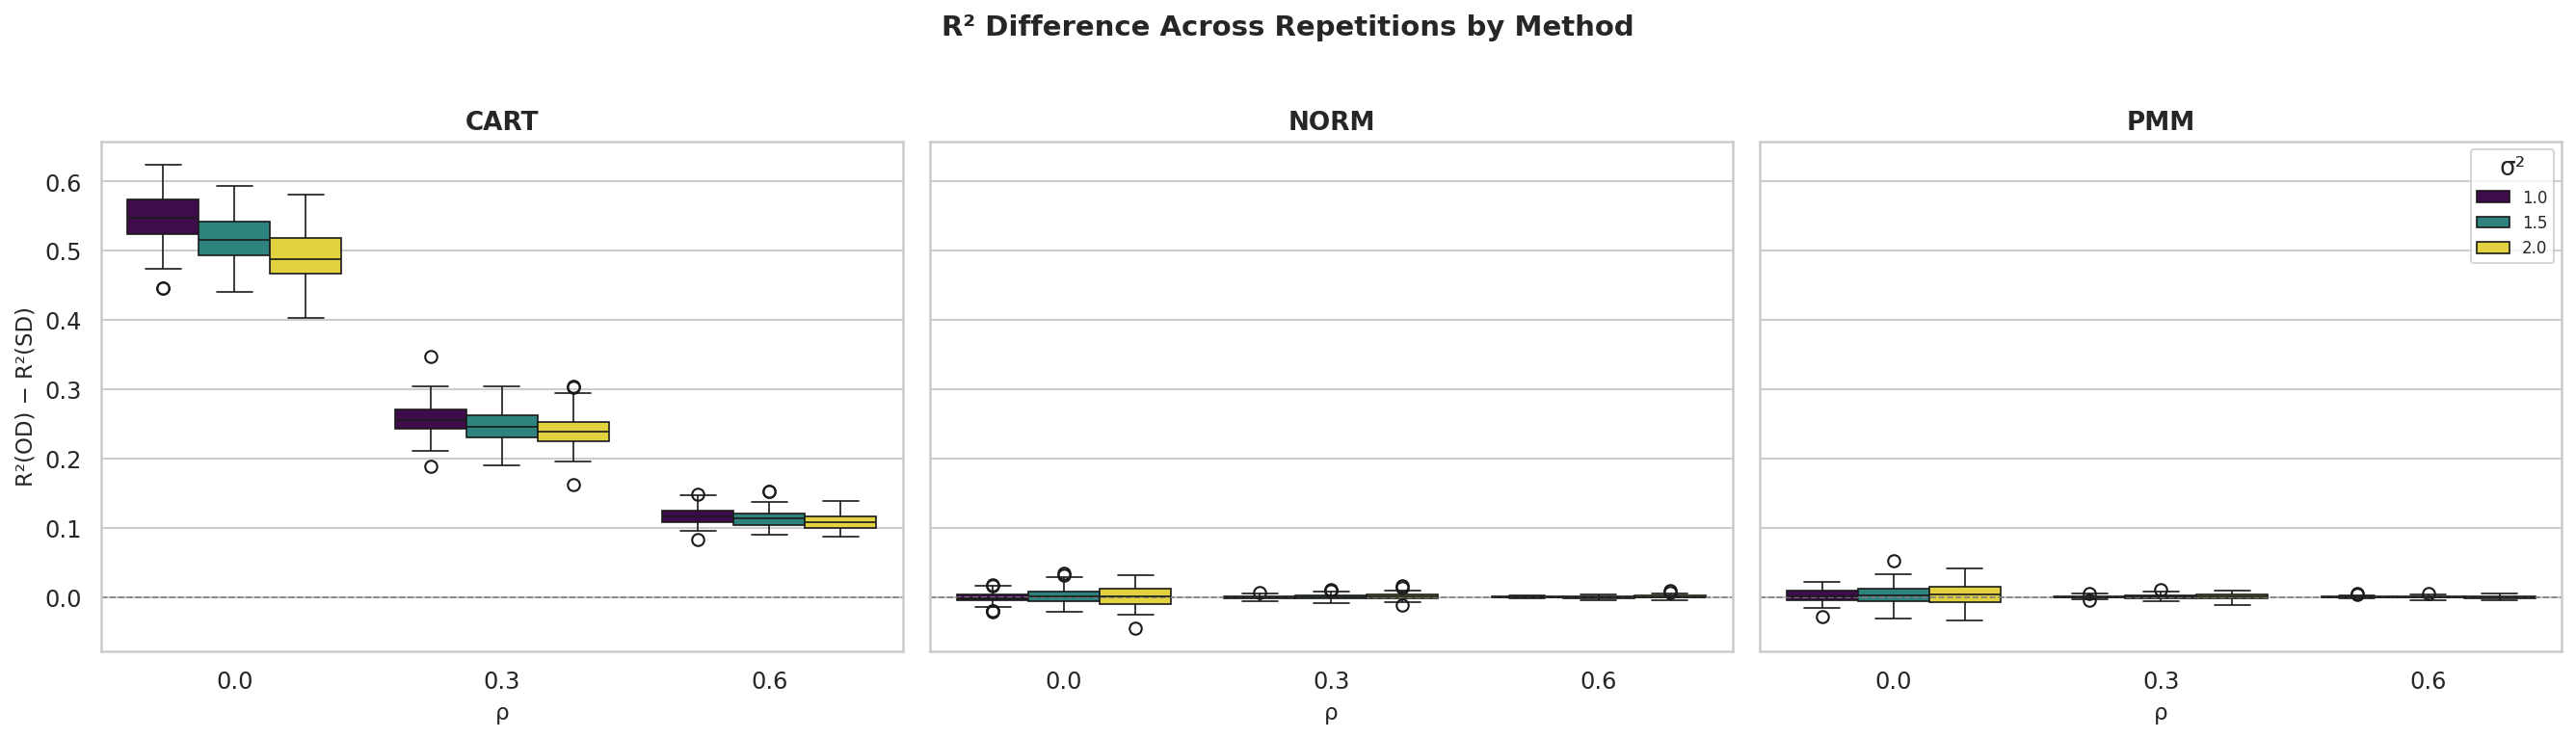

In [40]:
# ── Plot: R² Difference distribution — faceted by method ───────────────────
fig, axes = plt.subplots(1, len(methods), figsize=(6 * len(methods), 5),
                         sharey=True)
if len(methods) == 1:
    axes = [axes]

for ax, method in zip(axes, methods):
    sub = results_df[results_df["method"] == method]
    sns.boxplot(
        data=sub, x="rho", y="r2_diff", hue="sigma_2",
        palette="viridis", ax=ax, linewidth=0.8,
    )
    ax.axhline(0, color="grey", ls="--", lw=0.8)
    ax.set_title(f"{method.upper()}")
    ax.set_xlabel("ρ")
    ax.set_ylabel("R²(OD) − R²(SD)" if ax == axes[0] else "")
    if ax != axes[-1]:
        ax.get_legend().remove() if ax.get_legend() else None
    else:
        ax.legend(title="σ²", fontsize=8)

plt.suptitle("R² Difference Across Repetitions by Method",
             fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(result_dir, "plot_r2_diff_by_method.png"),
            dpi=200, bbox_inches="tight")
plt.show()

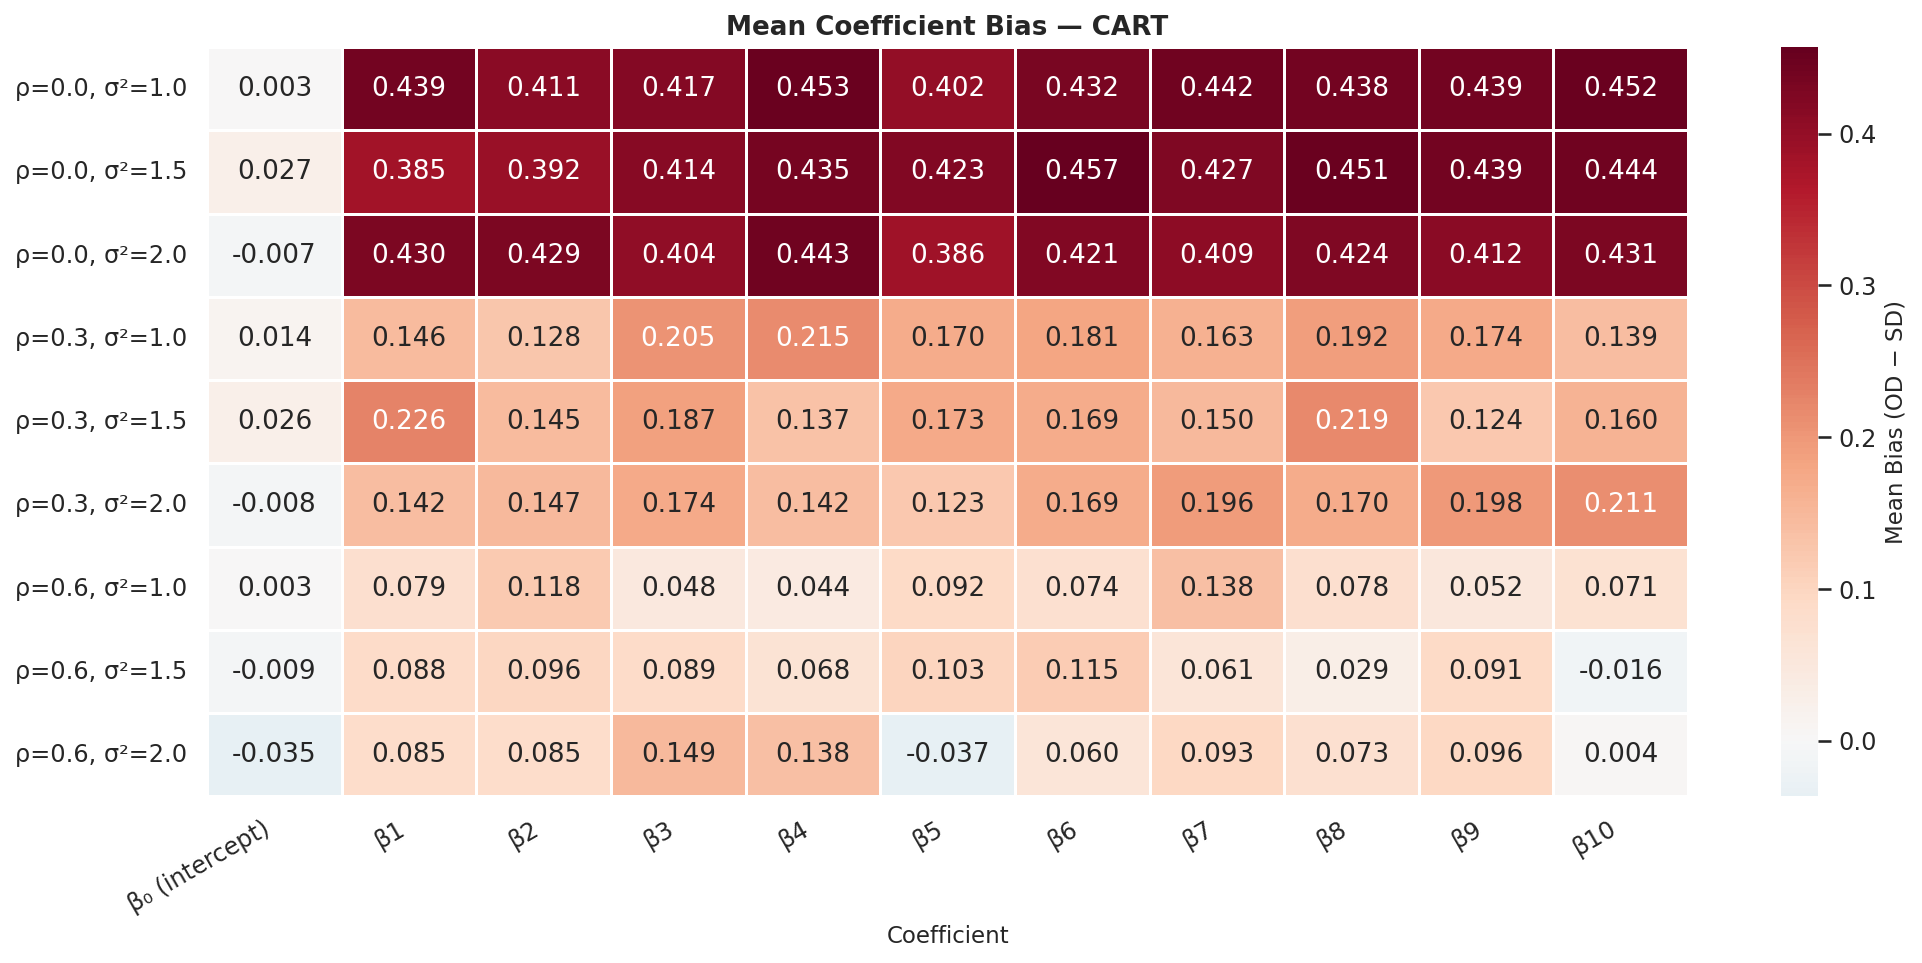

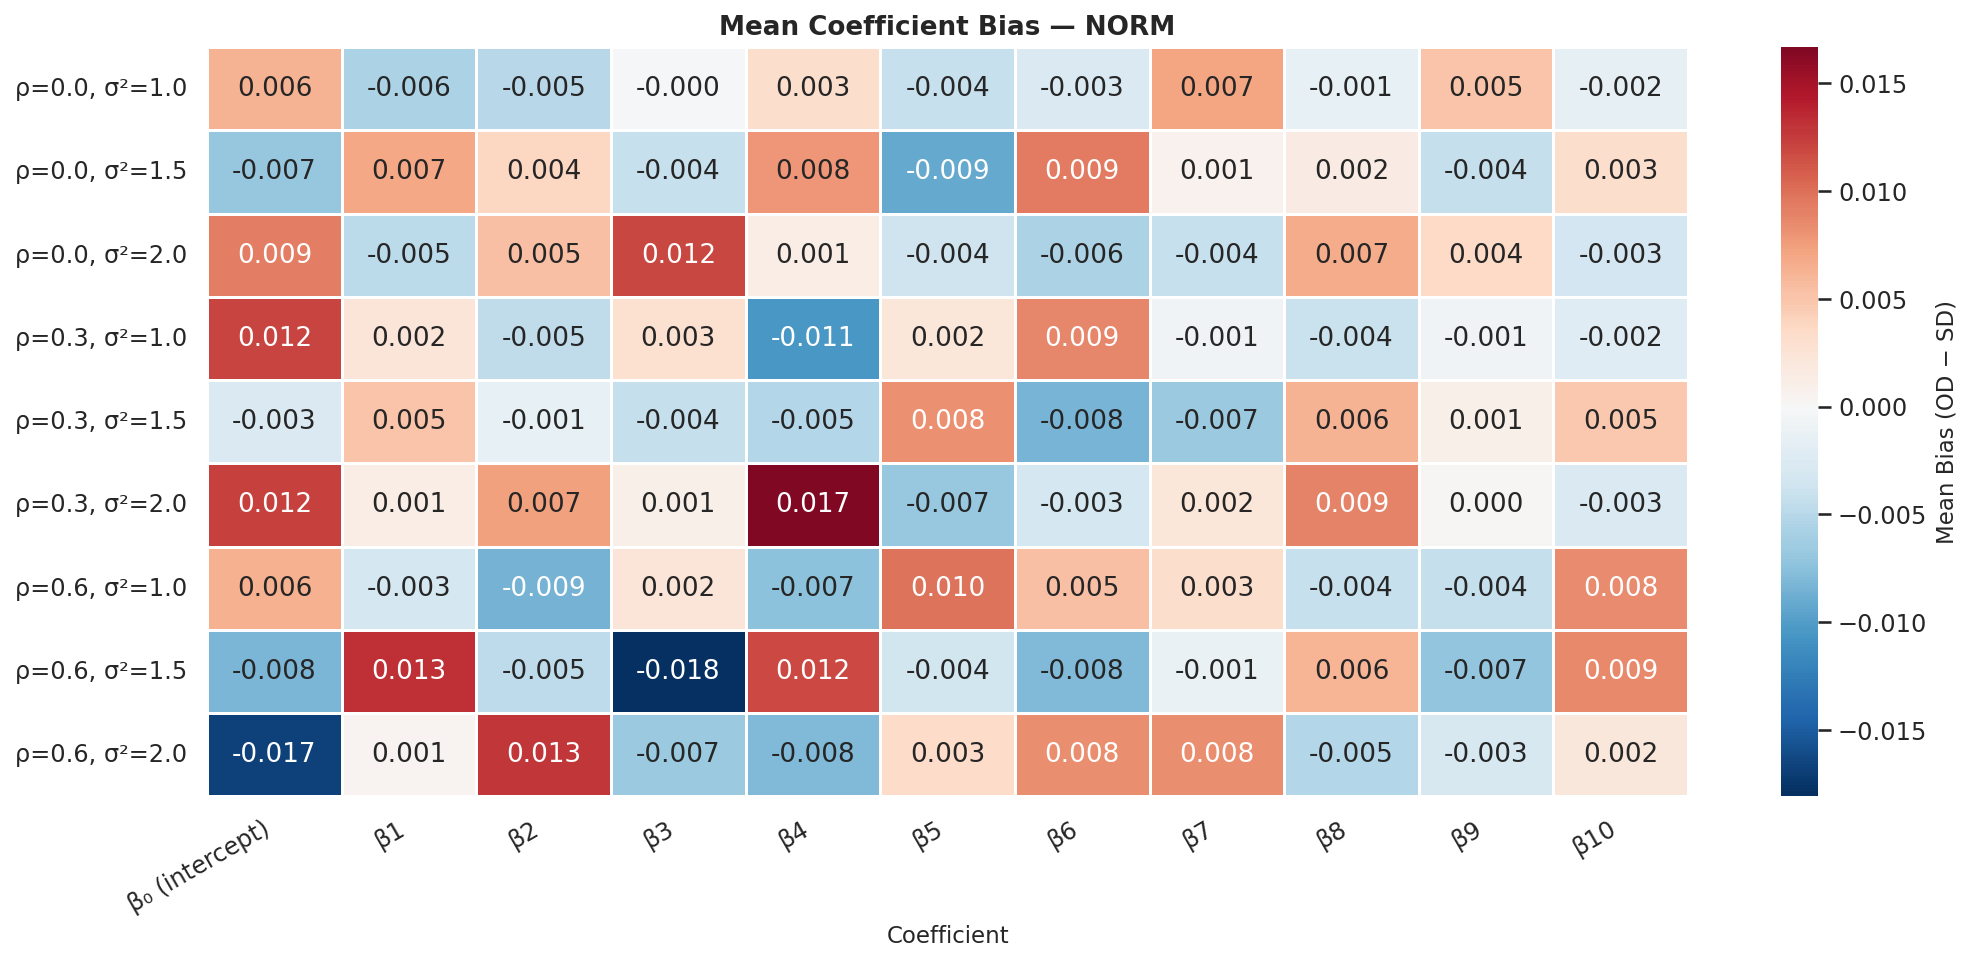

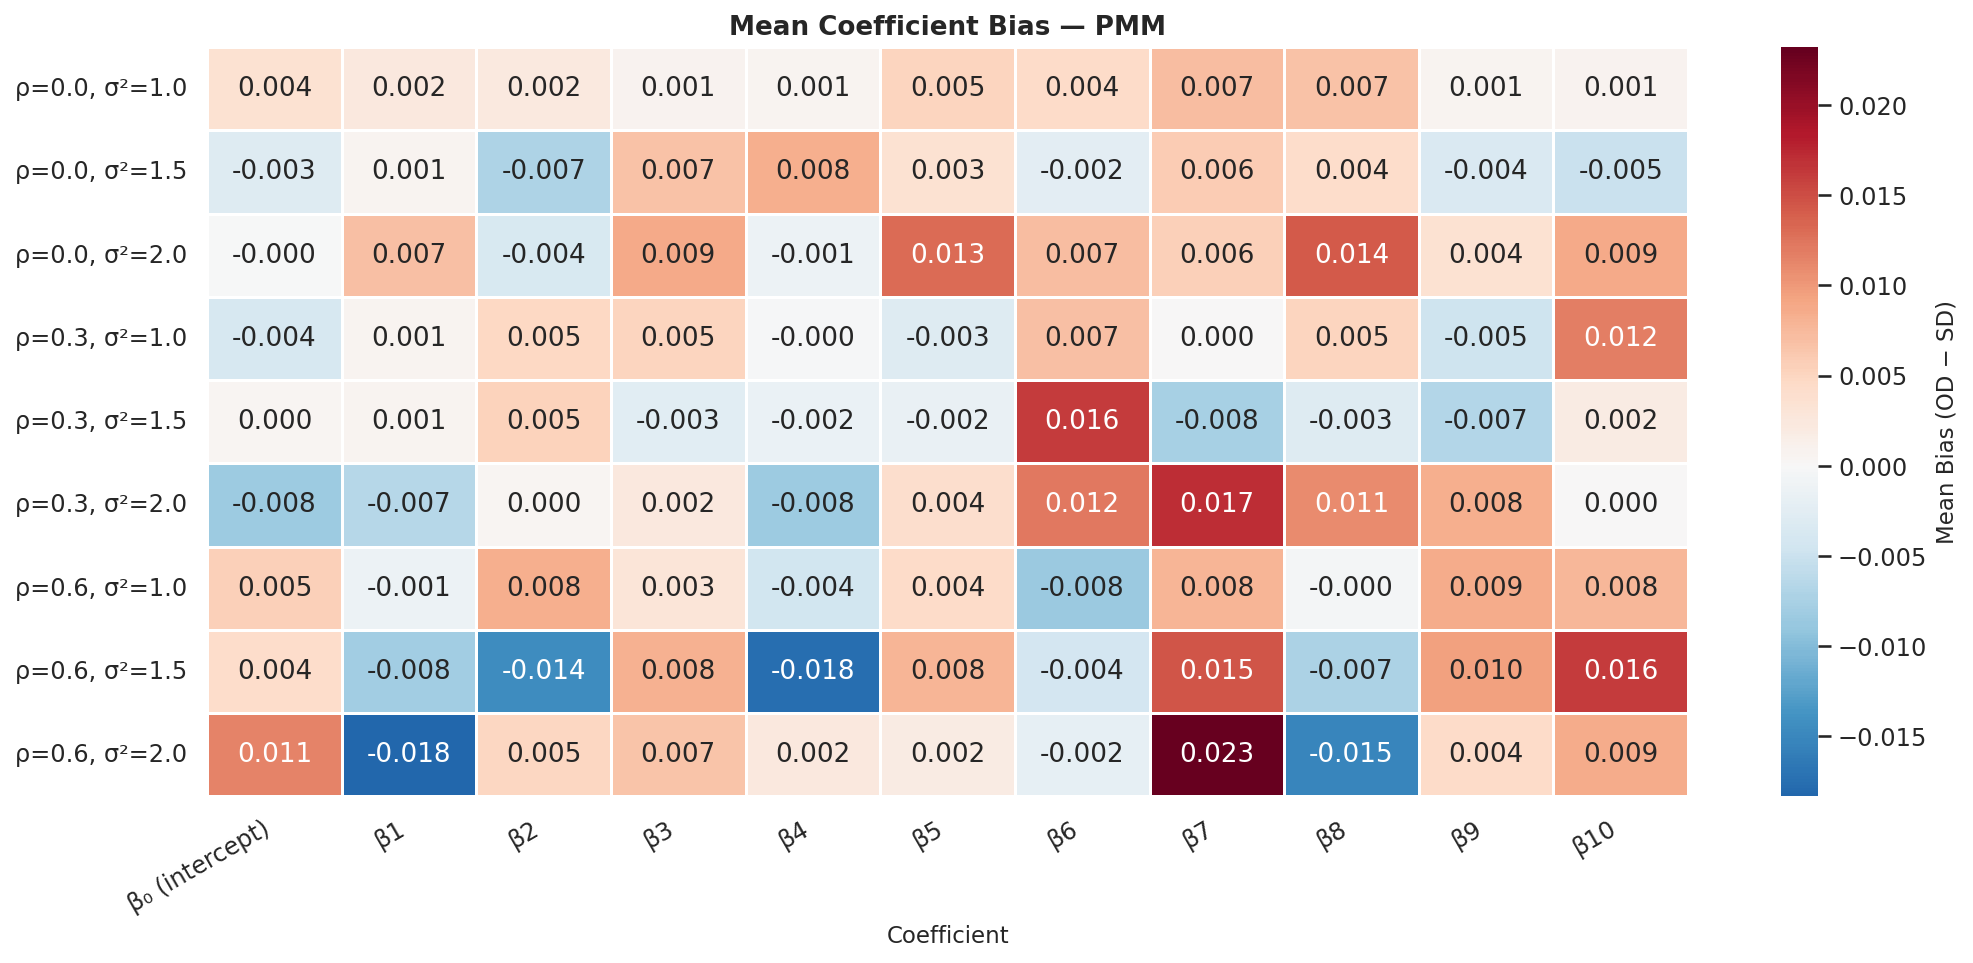

In [41]:
# ── Plot: Coefficient bias heatmap — one per method ────────────────────────
# Average (β_OD − β_SD) across all reps, for each (rho, sigma_2) × coefficient

for method in methods:
    sub = coef_df[coef_df["method"] == method]

    # Create scenario label
    sub = sub.copy()
    sub["scenario"] = sub.apply(lambda r: f"ρ={r['rho']}, σ²={r['sigma_2']}", axis=1)

    bias_pivot = (
        sub.groupby(["scenario", "term"])["diff"]
        .mean()
        .unstack("term")
    )
    # Reorder columns
    ordered_cols = ["β₀ (intercept)"] + [f"β{i+1}" for i in range(p)]
    bias_pivot = bias_pivot[[c for c in ordered_cols if c in bias_pivot.columns]]

    fig, ax = plt.subplots(figsize=(14, 3 + 0.4 * len(bias_pivot)))
    sns.heatmap(
        bias_pivot, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
        linewidths=0.5, ax=ax,
        cbar_kws={"label": "Mean Bias (OD − SD)"},
    )
    ax.set_title(f"Mean Coefficient Bias — {method.upper()}")
    ax.set_xlabel("Coefficient")
    ax.set_ylabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")

    plt.tight_layout()
    plt.savefig(os.path.join(result_dir, f"plot_coef_bias_heatmap_{method}.png"),
                dpi=200, bbox_inches="tight")
    plt.show()

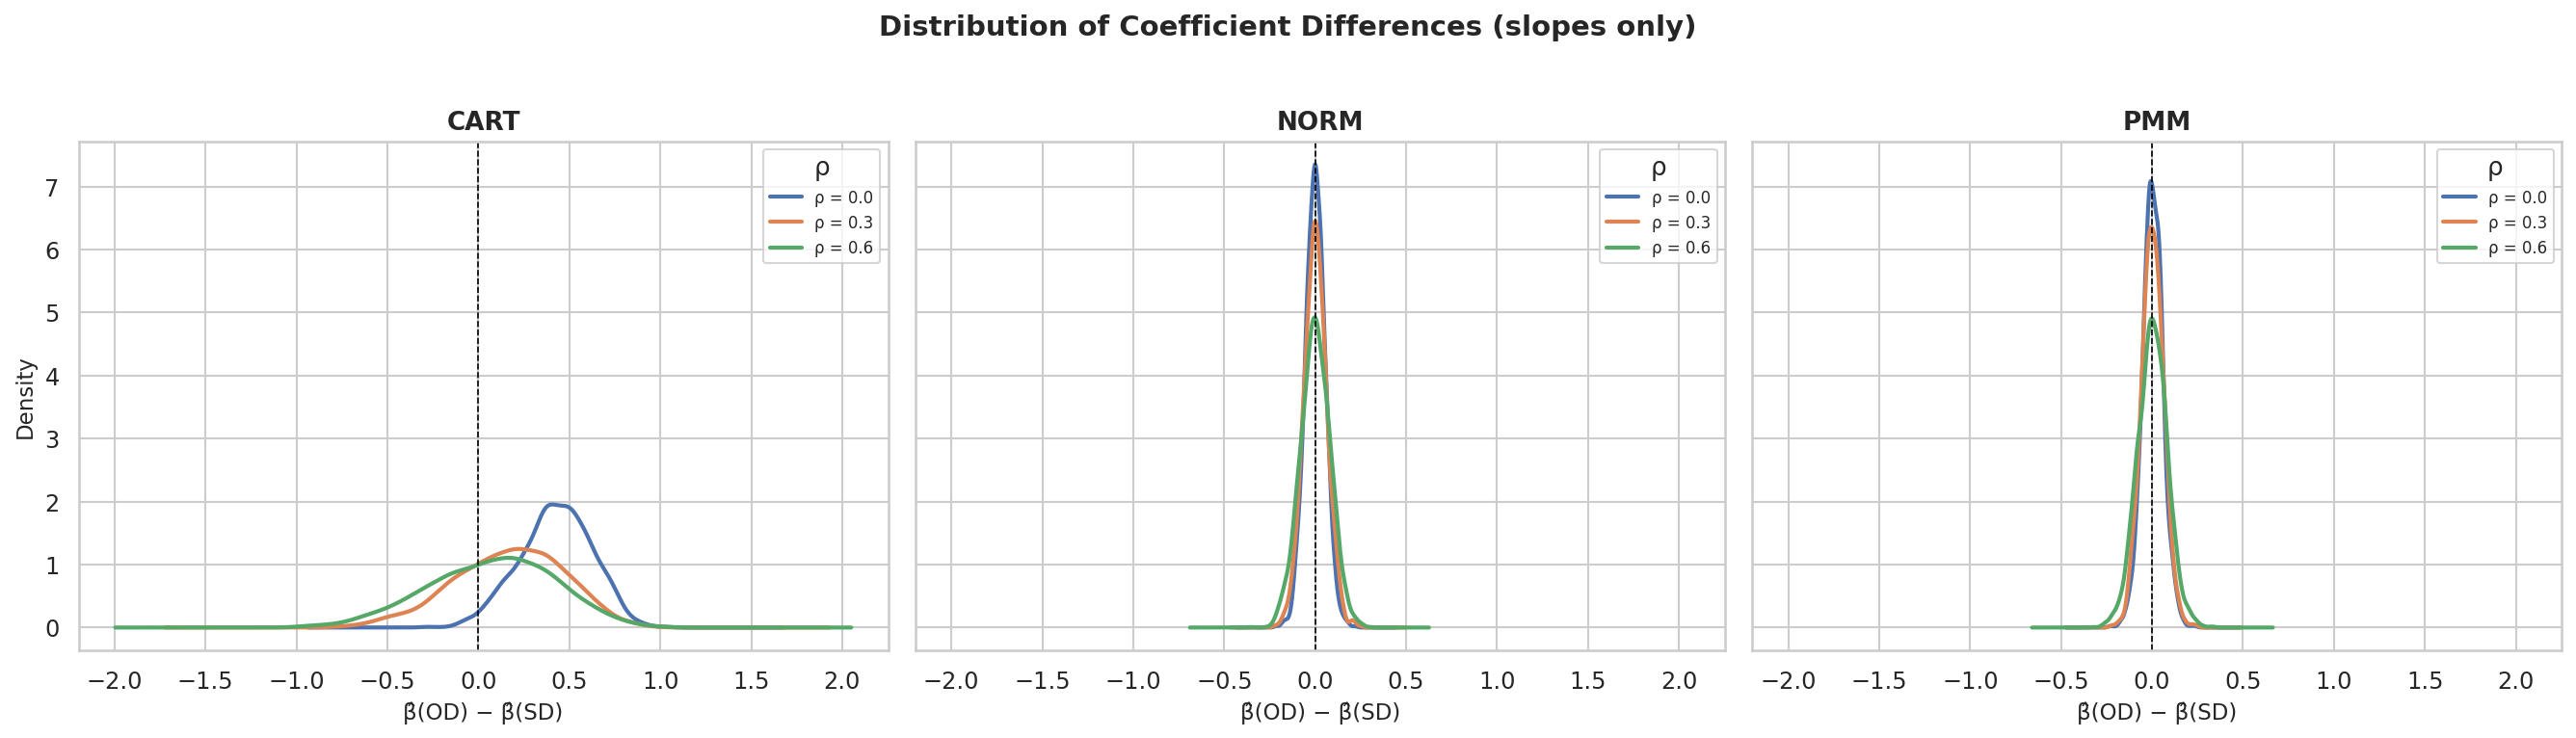


[DONE] Regression analysis complete. Models & results saved to ../models/ and ../results/


In [42]:
# ── KDE of coefficient differences — one per method ────────────────────────
slope_diff = coef_df[coef_df["term"] != "β₀ (intercept)"].copy()

fig, axes = plt.subplots(1, len(methods), figsize=(6 * len(methods), 5),
                         sharey=True, sharex=True)
if len(methods) == 1:
    axes = [axes]

for ax, method in zip(axes, methods):
    sub = slope_diff[slope_diff["method"] == method]
    for rho in rho_sorted:
        d = sub[sub["rho"] == rho]["diff"]
        d.plot.kde(ax=ax, linewidth=2, label=f"ρ = {rho}")

    ax.axvline(0, color="black", ls="--", lw=0.8)
    ax.set_title(f"{method.upper()}")
    ax.set_xlabel("β̂(OD) − β̂(SD)")
    ax.set_ylabel("Density" if ax == axes[0] else "")
    ax.legend(title="ρ", fontsize=8)

plt.suptitle("Distribution of Coefficient Differences (slopes only)",
             fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(result_dir, "plot_coef_diff_kde_by_method.png"),
            dpi=200, bbox_inches="tight")
plt.show()

print("\n[DONE] Regression analysis complete. Models & results saved to ../models/ and ../results/")